In [5]:
import warnings
warnings.filterwarnings("ignore")

import re
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import seaborn as sns
import networkx as nx
from scipy import stats
from scipy.signal import savgol_filter

from sklearn.cluster          import KMeans
from sklearn.ensemble         import (RandomForestClassifier,
                                      GradientBoostingClassifier,
                                      VotingClassifier,
                                      IsolationForest)
from sklearn.linear_model     import LogisticRegression
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.decomposition    import PCA
from sklearn.neighbors        import LocalOutlierFactor
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.metrics          import (accuracy_score, confusion_matrix,
                                      classification_report)
from sklearn.pipeline         import Pipeline




In [6]:
BG            = "#0D0D0D"
CARD          = "#141420"
SPOTIFY_GREEN = "#1DB954"
SPOTIFY_BLACK = "#191414"

PALETTE = ["#1DB954", "#FF6B6B", "#4ECDC4", "#FFE66D",
           "#A855F7", "#F97316", "#EC4899", "#06B6D4"]

plt.rcParams.update({
    "figure.facecolor" : BG,
    "axes.facecolor"   : CARD,
    "axes.edgecolor"   : "#252535",
    "axes.labelcolor"  : "#CCCCCC",
    "text.color"       : "#EEEEEE",
    "xtick.color"      : "#888888",
    "ytick.color"      : "#888888",
    "grid.color"       : "#1E1E2E",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.6,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 11.5,
    "axes.labelsize"   : 9.5,
    "xtick.labelsize"  : 8.5,
    "ytick.labelsize"  : 8.5,
    "legend.fontsize"  : 8.5,
    "legend.framealpha": 0.25,
    "legend.edgecolor" : "#333344",
})

GREEN_CMAP = LinearSegmentedColormap.from_list(
    "spotify_green", ["#0D0D0D", SPOTIFY_GREEN], N=256)
DIVRG_CMAP = sns.diverging_palette(10, 133, as_cmap=True)


def style_ax(ax, grid_axis="y"):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_edgecolor("#252535")
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.5)


def page_title(fig, y, text):
    fig.text(0.5, y, text, ha="center", va="center",
             fontsize=16, fontweight="bold", color=SPOTIFY_GREEN,
             path_effects=[pe.withStroke(linewidth=5, foreground=BG)])


def poly_trend(x, y, deg=2):
    c    = np.polyfit(x, y, deg)
    xfit = np.linspace(x.min(), x.max(), 200)
    return xfit, np.polyval(c, xfit)


def linear_forecast(x, y, ahead=3):
    slope, inter, _, _, _ = stats.linregress(x, y)
    r2   = stats.pearsonr(x, y)[0] ** 2
    xfut = np.arange(x.max() + 1, x.max() + ahead + 1)
    return xfut, slope * xfut + inter, slope, r2



In [8]:
print("=" * 65)
print("  SPOTIFY 2014–2020  ·  DATA SCIENCE PORTFOLIO")
print("=" * 65)

raw = pd.read_csv("/Users/canberkyilmaz/Downloads/spotify_2014_2020_dataset.csv")
df  = raw[raw["Duration_Min"] < 30].copy()

# ── Time features
try:
    dt = pd.to_datetime(df["Release_Date"], errors="coerce")
    df["Release_Month"]   = dt.dt.month.fillna(6).astype(int)
    df["Release_Quarter"] = dt.dt.quarter.fillna(2).astype(int)
except Exception:
    df["Release_Month"]   = 6
    df["Release_Quarter"] = 2

# ── Text / structural features
df["Artist_Count"]    = df["Artists"].apply(lambda x: len(str(x).split(",")))
df["Name_Length"]     = df["Track_Name"].apply(len)
df["Word_Count"]      = df["Track_Name"].apply(lambda x: len(str(x).split()))
df["Has_Feat"]        = df["Track_Name"].str.lower().str.contains(r"feat|ft\.").astype(int)
df["Has_Remix"]       = df["Track_Name"].str.lower().str.contains(r"remix").astype(int)
df["Has_Number"]      = df["Track_Name"].str.contains(r"\d").astype(int)
df["Has_Parenthesis"] = df["Track_Name"].str.contains(r"[\(\[]").astype(int)
df["Is_Collab"]       = (df["Artist_Count"] > 1).astype(int)

# ── Numeric transformations
df["Duration_Log"]    = np.log1p(df["Duration_Min"])
df["Duration_Sq"]     = df["Duration_Min"] ** 2
df["Artist_x_Dur"]    = df["Artist_Count"] * df["Duration_Min"]
df["Year_Norm"]       = (df["Year"] - df["Year"].min()) / (
                         df["Year"].max() - df["Year"].min())
df["Is_Summer"]       = df["Release_Month"].isin([6, 7, 8]).astype(int)

# ── Information entropy of track name
def char_entropy(text):
    freq = collections.Counter(text.lower())
    total = len(text)
    return -sum((c / total) * np.log2(c / total + 1e-9) for c in freq.values())

df["Name_Entropy"] = df["Track_Name"].apply(char_entropy)

# ── Label encoding
le = LabelEncoder()
df["Query_Encoded"] = le.fit_transform(df["Query"])

FEATURE_COLS = [
    "Duration_Min", "Duration_Log", "Artist_Count", "Name_Length",
    "Year", "Is_Collab", "Word_Count", "Has_Feat", "Has_Remix",
    "Has_Number", "Has_Parenthesis", "Name_Entropy", "Artist_x_Dur",
    "Release_Month", "Release_Quarter", "Is_Summer",
]

print(f"\n  Tracks  : {len(df):,}")
print(f"  Features: {len(FEATURE_COLS)} engineered")
print(f"  Years   : {df['Year'].min()} – {df['Year'].max()}")
print(f"  Queries : {', '.join(le.classes_)}\n")



  SPOTIFY 2014–2020  ·  DATA SCIENCE PORTFOLIO

  Tracks  : 1,699
  Features: 16 engineered
  Years   : 2014 – 2020
  Queries : love, night, remix, rock, sad



✓  Page 1 – EDA saved


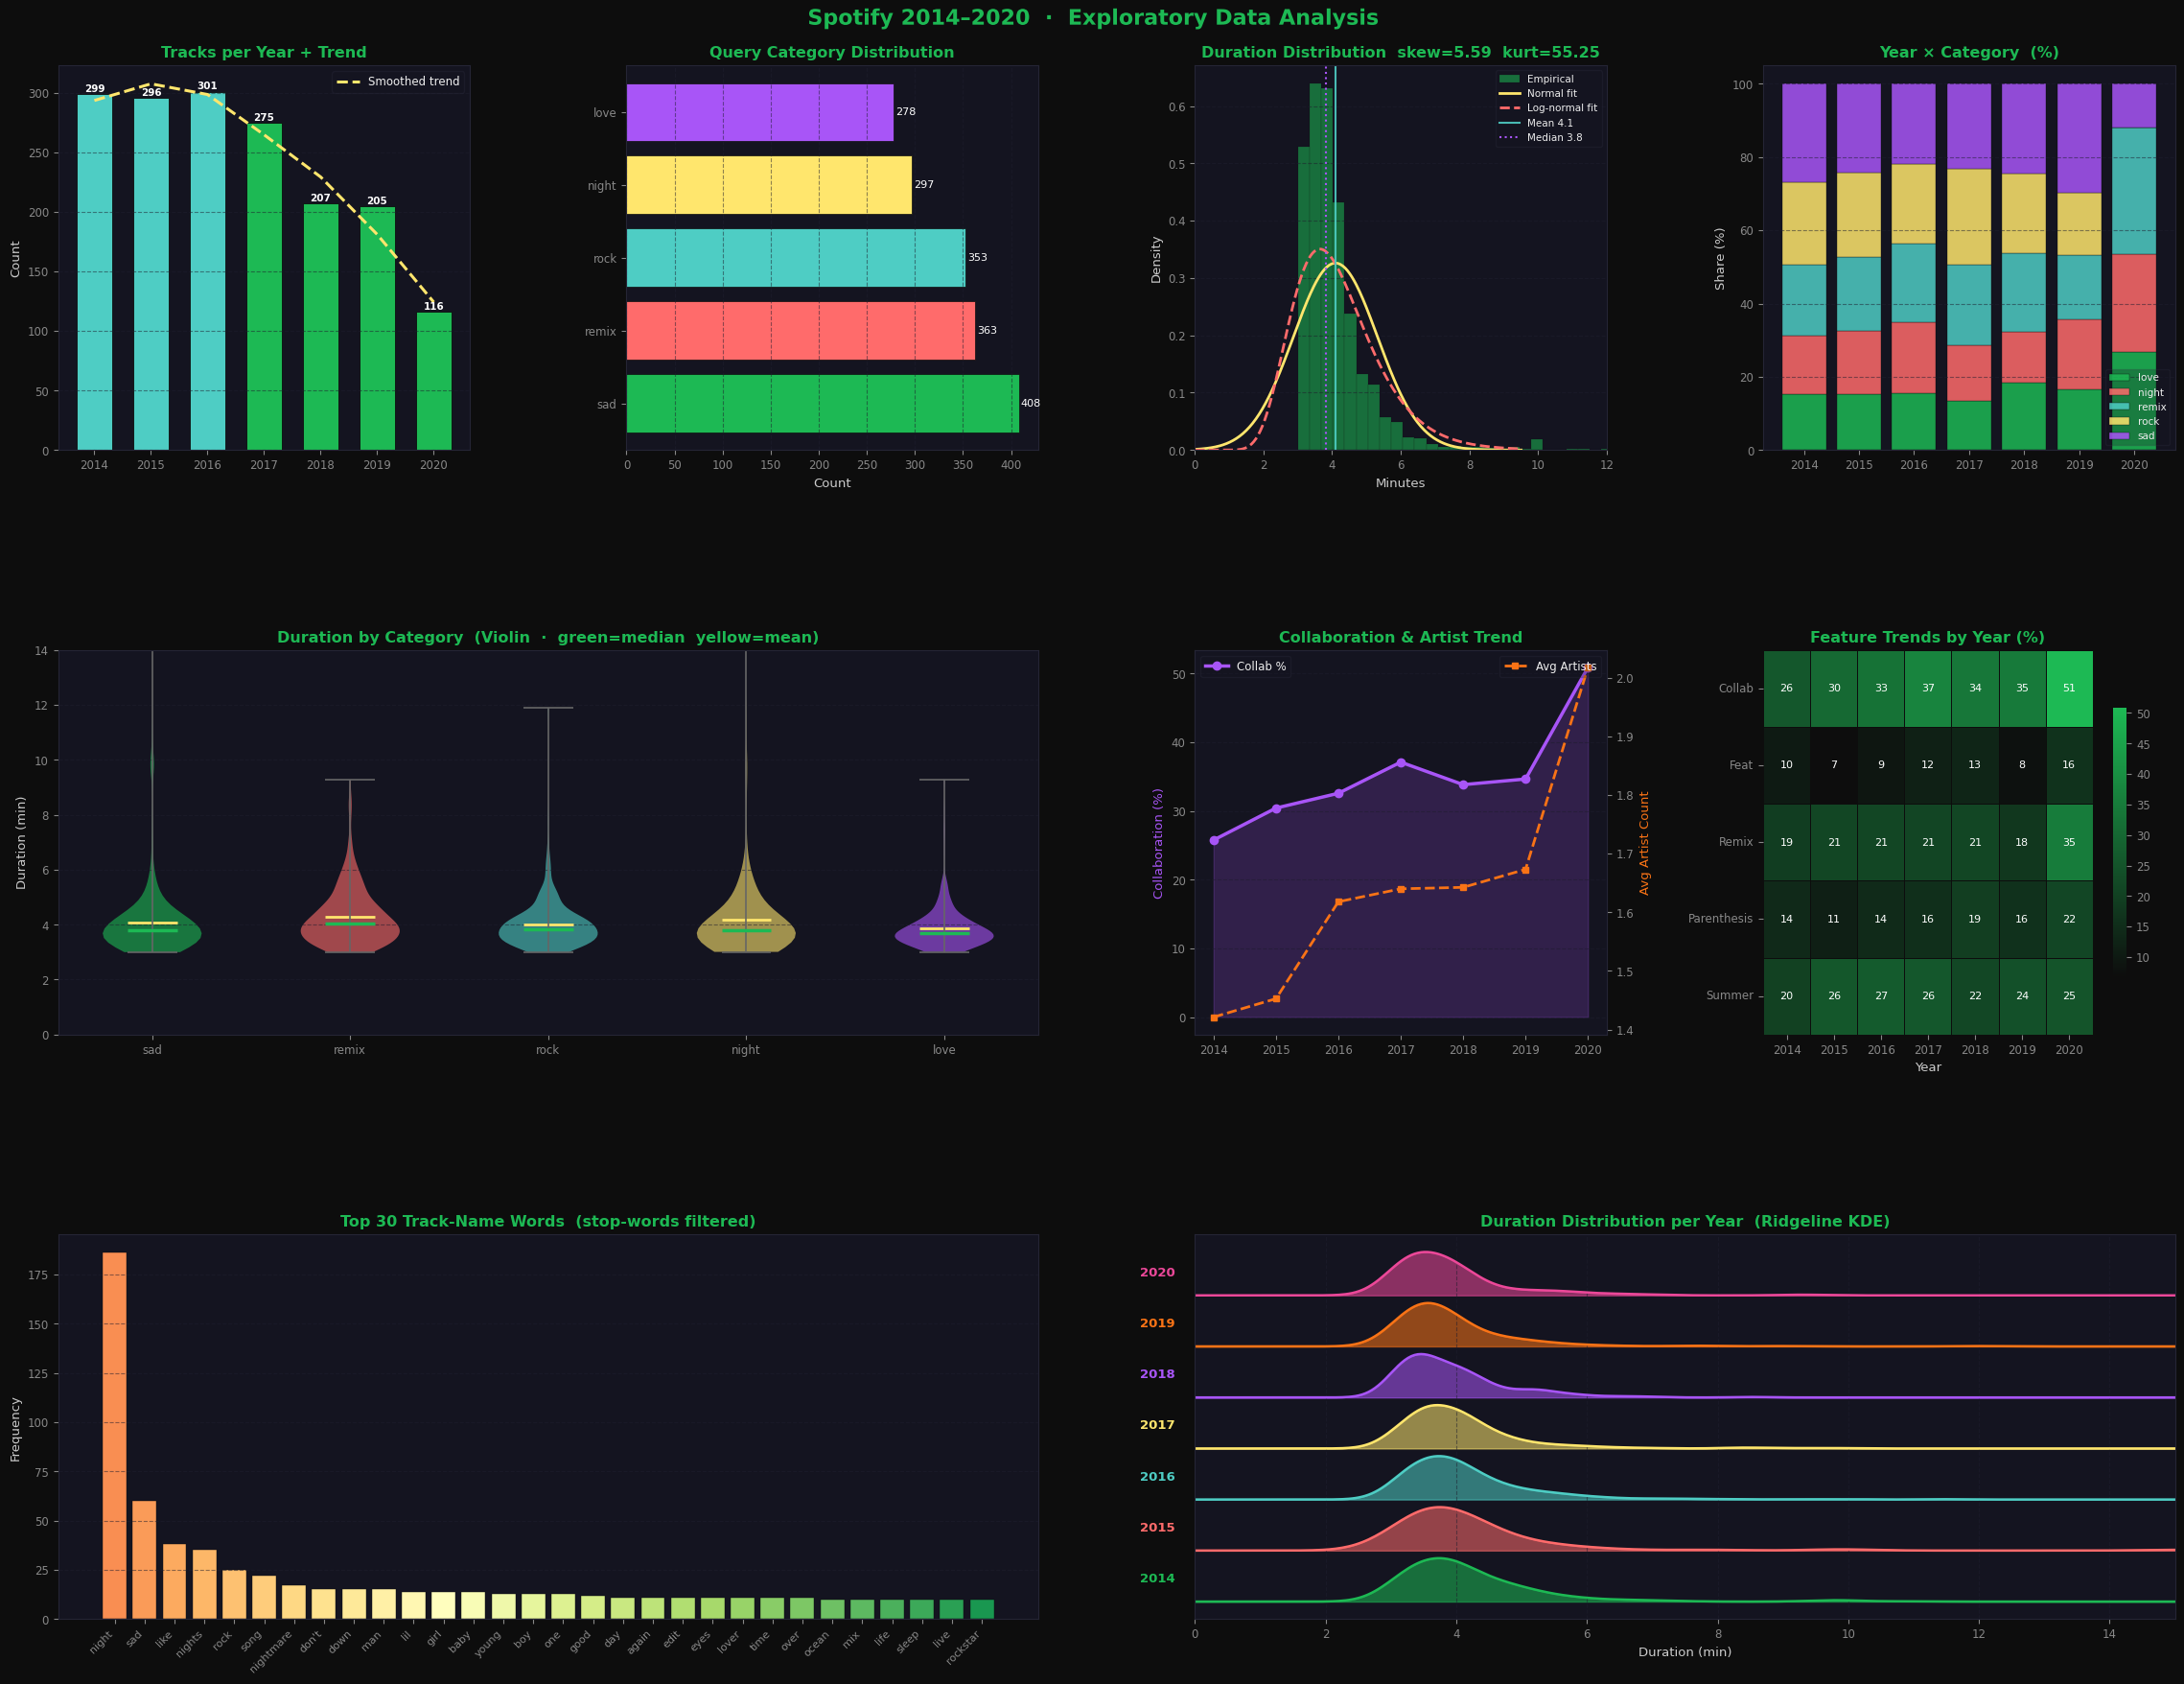

In [10]:
fig1 = plt.figure(figsize=(24, 18), facecolor=BG)
page_title(fig1, 0.977,
           "Spotify 2014–2020  ·  Exploratory Data Analysis")
gs1 = gridspec.GridSpec(3, 4, fig1, hspace=0.52, wspace=0.38,
                         top=0.95, bottom=0.05, left=0.05, right=0.97)

# ── 1-A  Track count per year + Savitzky-Golay smoothed trend
ax = fig1.add_subplot(gs1[0, 0])
style_ax(ax)
yc   = df.groupby("Year").size()
clrs = [SPOTIFY_GREEN if y >= 2017 else "#4ECDC4" for y in yc.index]
bars = ax.bar(yc.index, yc.values, color=clrs, width=0.62,
              edgecolor=BG, linewidth=0.6)
smooth = savgol_filter(yc.values, 5, 2)
ax.plot(yc.index, smooth, color="#FFE66D", lw=2.2, ls="--",
        label="Smoothed trend")
for b, v in zip(bars, yc.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 2, str(v),
            ha="center", fontsize=7.5, color="white", fontweight="bold")
ax.set_title("Tracks per Year + Trend", color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Count")
ax.legend()

# ── 1-B  Category breakdown – horizontal bars
ax = fig1.add_subplot(gs1[0, 1])
style_ax(ax, "x")
qc   = df["Query"].value_counts()
bars = ax.barh(qc.index, qc.values, color=PALETTE[:len(qc)],
               edgecolor=BG, linewidth=0.5)
for b, v in zip(bars, qc.values):
    ax.text(v + 2, b.get_y() + b.get_height() / 2, str(v),
            va="center", fontsize=8, color="white")
ax.set_title("Query Category Distribution", color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Count")

# ── 1-C  Duration histogram with distribution fits
ax = fig1.add_subplot(gs1[0, 2])
style_ax(ax)
dur = df["Duration_Min"]
ax.hist(dur, bins=50, density=True, color=SPOTIFY_GREEN,
        alpha=0.55, edgecolor=BG, linewidth=0.2, label="Empirical")
xr = np.linspace(0, dur.quantile(0.99), 300)
ax.plot(xr, stats.norm.pdf(xr, dur.mean(), dur.std()),
        color="#FFE66D", lw=2, label="Normal fit")
ax.plot(xr, stats.lognorm.pdf(xr, s=dur.std() / dur.mean(),
        scale=np.exp(np.log(dur).mean())),
        color="#FF6B6B", lw=2, ls="--", label="Log-normal fit")
ax.axvline(dur.mean(),   color="#4ECDC4", lw=1.5, alpha=0.9,
           label=f"Mean {dur.mean():.1f}")
ax.axvline(dur.median(), color="#A855F7", lw=1.5, ls=":",
           label=f"Median {dur.median():.1f}")
ax.set_xlim(0, 12)
sk, ku = stats.skew(dur), stats.kurtosis(dur)
ax.set_title(f"Duration Distribution  skew={sk:.2f}  kurt={ku:.2f}",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Minutes")
ax.set_ylabel("Density")
ax.legend(fontsize=7.5)
# ── 1-D  Year × Query stacked %
ax = fig1.add_subplot(gs1[0, 3])
style_ax(ax)
pivot     = df.groupby(["Year", "Query"]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
bottom    = np.zeros(len(pivot_pct))
for i, col in enumerate(pivot_pct.columns):
    ax.bar(pivot_pct.index, pivot_pct[col], bottom=bottom,
           label=col, color=PALETTE[i], alpha=0.85, edgecolor=BG,
           linewidth=0.3)
    bottom += pivot_pct[col].values
ax.set_title("Year × Category  (%)", color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Share (%)")
ax.legend(fontsize=7.5, loc="lower right")

# ── 1-E  Violin – duration by category
ax = fig1.add_subplot(gs1[1, :2])
style_ax(ax)
cats     = list(qc.index)
vio_data = [df[df["Query"] == c]["Duration_Min"].values for c in cats]
parts    = ax.violinplot(vio_data, positions=range(len(cats)),
                          showmedians=True, showmeans=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.6)
for k in ["cbars", "cmins", "cmaxes"]:
    parts[k].set_color("#666")
    parts[k].set_linewidth(1.2)
parts["cmedians"].set_color(SPOTIFY_GREEN)
parts["cmedians"].set_linewidth(2.5)
parts["cmeans"].set_color("#FFE66D")
parts["cmeans"].set_linewidth(2)
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats)
ax.set_ylim(0, 14)
ax.set_title("Duration by Category  (Violin  ·  green=median  yellow=mean)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Duration (min)")

# ── 1-F  Collaboration & artist count dual-axis trend
ax = fig1.add_subplot(gs1[1, 2])
style_ax(ax)
collab_yr  = df.groupby("Year")["Is_Collab"].mean() * 100
artist_yr  = df.groupby("Year")["Artist_Count"].mean()
ax2t       = ax.twinx()
ax.fill_between(collab_yr.index, collab_yr.values,
                alpha=0.2, color="#A855F7")
ax.plot(collab_yr.index, collab_yr.values,
        color="#A855F7", lw=2.5, marker="o", ms=6, label="Collab %")
ax2t.plot(artist_yr.index, artist_yr.values,
          color="#F97316", lw=2, marker="s", ms=5, ls="--",
          label="Avg Artists")
ax.set_ylabel("Collaboration (%)", color="#A855F7")
ax2t.set_ylabel("Avg Artist Count", color="#F97316")
ax.set_title("Collaboration & Artist Trend", color=SPOTIFY_GREEN, fontweight="bold")
ax.legend(loc="upper left")
ax2t.legend(loc="upper right")
# ── 1-G  Feature trend heatmap
ax = fig1.add_subplot(gs1[1, 3])
style_ax(ax, None)
feat_yr = df.groupby("Year")[["Is_Collab", "Has_Feat", "Has_Remix",
                               "Has_Parenthesis", "Is_Summer"]].mean() * 100
sns.heatmap(feat_yr.T, ax=ax, cmap=GREEN_CMAP,
            annot=True, fmt=".0f", annot_kws={"size": 8},
            linewidths=0.4, linecolor=BG,
            cbar_kws={"shrink": 0.7})
ax.set_title("Feature Trends by Year (%)", color=SPOTIFY_GREEN, fontweight="bold")
ax.set_yticklabels(["Collab", "Feat", "Remix", "Parenthesis", "Summer"],
                   fontsize=8.5, rotation=0)
ax.set_xticklabels(feat_yr.index, rotation=0)

# ── 1-H  Top-30 track-name words
ax = fig1.add_subplot(gs1[2, :2])
style_ax(ax)
STOPWORDS = {
    "the","a","an","of","in","on","at","to","and","is","it","my","me",
    "you","i","feat","ft","remix","version","official","with","your",
    "love","for","by","be","that","so","no","do","its","this","all",
    "we","are","was","has","he","she","they","from","just","not","out",
    "up","but","oh","im","get","can","let","ve","re","da","de","la",
}
words = [
    w for name in df["Track_Name"]
    for w in re.findall(r"[a-zA-Z']+", name.lower())
    if w not in STOPWORDS and len(w) > 2
]
wfreq = pd.Series(words).value_counts().head(30)
clrs_w = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(wfreq)))
ax.bar(range(len(wfreq)), wfreq.values, color=clrs_w,
       edgecolor=BG, linewidth=0.3)
ax.set_xticks(range(len(wfreq)))
ax.set_xticklabels(wfreq.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Top 30 Track-Name Words  (stop-words filtered)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Frequency")
# ── 1-I  Ridgeline – duration KDE per year
ax = fig1.add_subplot(gs1[2, 2:])
style_ax(ax, "x")
years_u = sorted(df["Year"].unique())
for i, yr in enumerate(years_u):
    d    = df[df["Year"] == yr]["Duration_Min"].clip(0, 15)
    kde  = stats.gaussian_kde(d)
    xkde = np.linspace(0, 15, 300)
    yk   = kde(xkde)
    yk   = yk / yk.max() * 0.85
    ax.fill_between(xkde, i + yk, i, alpha=0.55, color=PALETTE[i])
    ax.plot(xkde, i + yk, color=PALETTE[i], lw=1.8)
    ax.text(-0.3, i + 0.38, str(yr), ha="right",
            fontsize=9.5, color=PALETTE[i], fontweight="bold")
ax.set_xlim(0, 15)
ax.set_yticks([])
ax.set_xlabel("Duration (min)")
ax.set_title("Duration Distribution per Year  (Ridgeline KDE)",
             color=SPOTIFY_GREEN, fontweight="bold")

fig1.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page1_eda.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 1 – EDA saved")


✓  Page 2 – Statistical Deep Dive saved


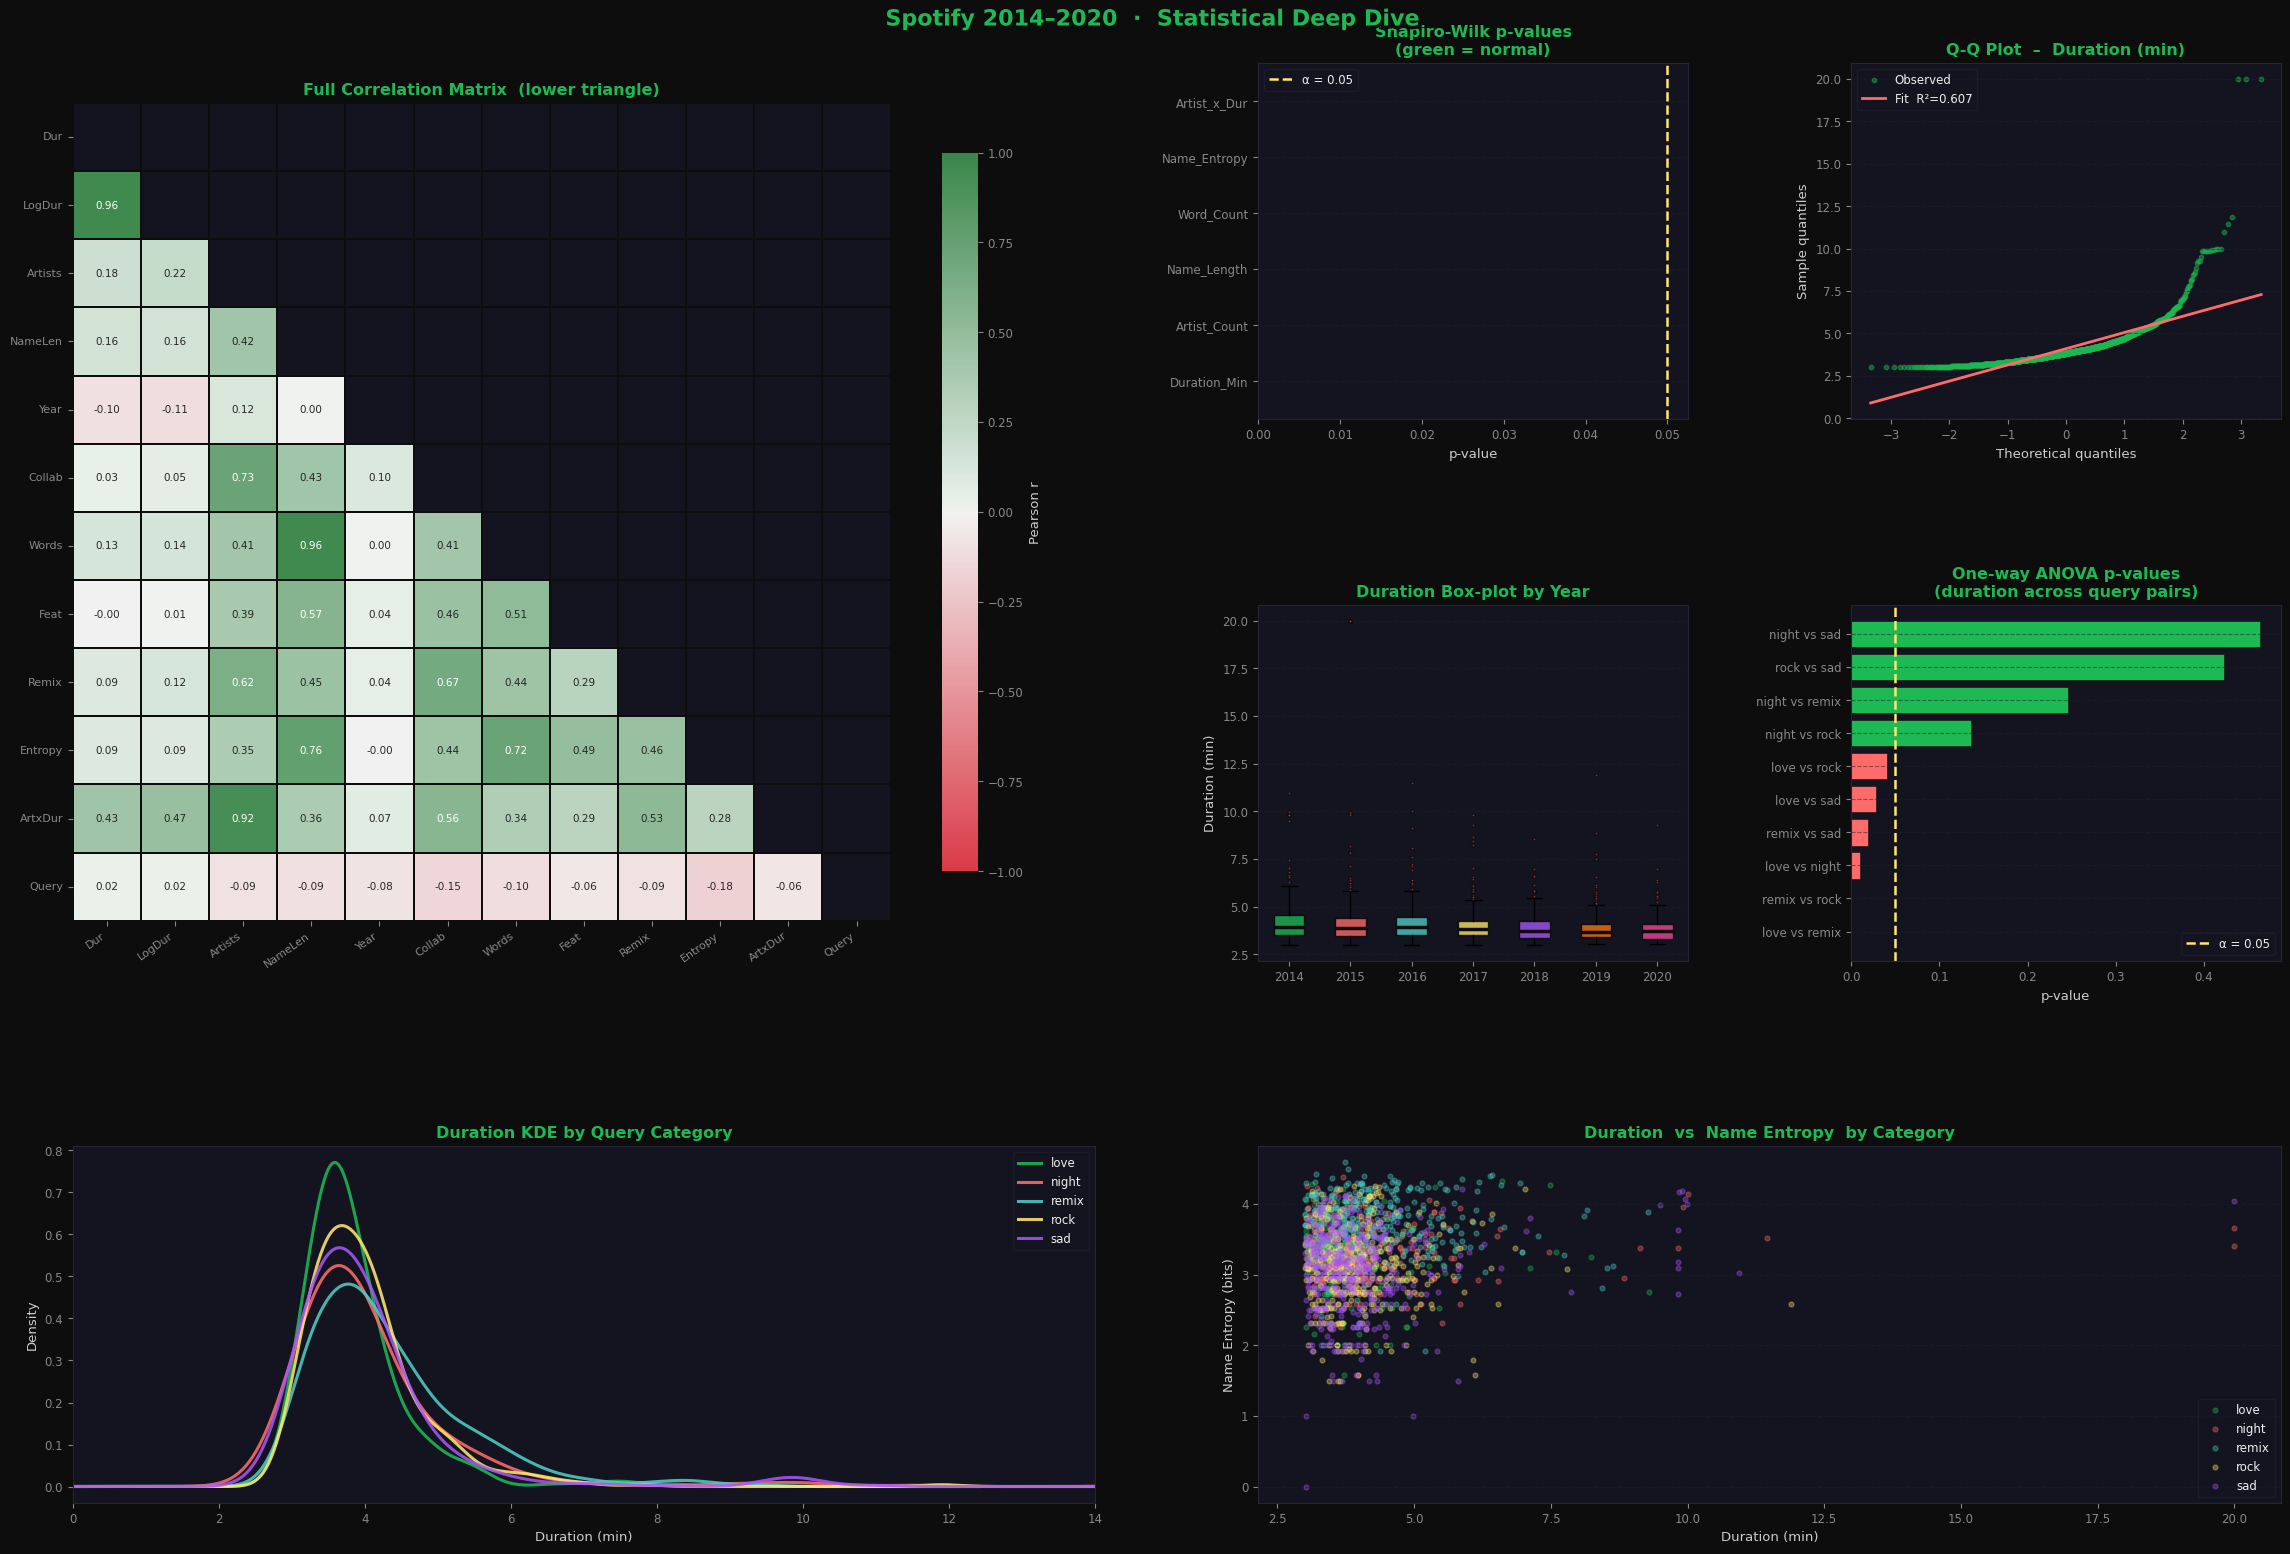

In [12]:
fig2 = plt.figure(figsize=(24, 16), facecolor=BG)
page_title(fig2, 0.977,
           "Spotify 2014–2020  ·  Statistical Deep Dive")
gs2 = gridspec.GridSpec(3, 4, fig2, hspace=0.52, wspace=0.38,
                         top=0.95, bottom=0.05, left=0.05, right=0.97)

# ── 2-A  Full correlation matrix
ax = fig2.add_subplot(gs2[0:2, 0:2])
style_ax(ax, None)
corr_cols = ["Duration_Min", "Duration_Log", "Artist_Count",
             "Name_Length", "Year", "Is_Collab", "Word_Count",
             "Has_Feat", "Has_Remix", "Name_Entropy",
             "Artist_x_Dur", "Query_Encoded"]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, cmap=DIVRG_CMAP, mask=mask,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7.5}, square=True,
            linewidths=0.3, linecolor=BG,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
short_lbl = ["Dur", "LogDur", "Artists", "NameLen", "Year",
             "Collab", "Words", "Feat", "Remix", "Entropy",
             "ArtxDur", "Query"]
ax.set_xticklabels(short_lbl, fontsize=8, rotation=35, ha="right")
ax.set_yticklabels(short_lbl, fontsize=8, rotation=0)
ax.set_title("Full Correlation Matrix  (lower triangle)",
             color=SPOTIFY_GREEN, fontweight="bold")

# ── 2-B  Normality tests (Shapiro-Wilk) per numeric feature
ax = fig2.add_subplot(gs2[0, 2])
style_ax(ax)
test_cols = ["Duration_Min", "Artist_Count", "Name_Length",
             "Word_Count", "Name_Entropy", "Artist_x_Dur"]
pvals = []
for col in test_cols:
    sample = df[col].sample(min(500, len(df)), random_state=42)
    _, p   = stats.shapiro(sample)
    pvals.append(p)
clrs_sw = [SPOTIFY_GREEN if p > 0.05 else "#FF6B6B" for p in pvals]
ax.barh(test_cols, pvals, color=clrs_sw, edgecolor=BG, linewidth=0.4)
ax.axvline(0.05, color="#FFE66D", lw=1.8, ls="--", label="α = 0.05")
ax.set_title("Shapiro-Wilk p-values\n(green = normal)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("p-value")
ax.legend()
# ── 2-C  Q-Q plot for duration
ax = fig2.add_subplot(gs2[0, 3])
style_ax(ax)
osm, osr = stats.probplot(df["Duration_Min"], dist="norm")[:2]
(osm_x, osm_y), (slope, inter, r) = stats.probplot(
    df["Duration_Min"], dist="norm")
ax.scatter(osm_x, osm_y, color=SPOTIFY_GREEN, alpha=0.45,
           s=10, label="Observed")
fit_line = slope * np.array(osm_x) + inter
ax.plot(osm_x, fit_line, color="#FF6B6B", lw=2, label=f"Fit  R²={r**2:.3f}")
ax.set_title("Q-Q Plot  –  Duration (min)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend()

# ── 2-D  Box-plot duration by year
ax = fig2.add_subplot(gs2[1, 2])
style_ax(ax)
yr_data = [df[df["Year"] == y]["Duration_Min"].values
           for y in years_u]
bp = ax.boxplot(yr_data, patch_artist=True,
                medianprops={"color": BG, "lw": 2.5},
                flierprops={"marker": ".", "ms": 3.5,
                             "markerfacecolor": "#FF6B6B",
                             "alpha": 0.5})
for patch, c in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(c)
    patch.set_alpha(0.78)
ax.set_xticklabels(years_u)
ax.set_title("Duration Box-plot by Year",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Duration (min)")
# ── 2-E  ANOVA p-values: duration across categories
ax = fig2.add_subplot(gs2[1, 3])
style_ax(ax)
anova_pairs = []
query_list  = list(le.classes_)
for i in range(len(query_list)):
    for j in range(i + 1, len(query_list)):
        g1 = df[df["Query"] == query_list[i]]["Duration_Min"]
        g2 = df[df["Query"] == query_list[j]]["Duration_Min"]
        _, p = stats.f_oneway(g1, g2)
        anova_pairs.append((f"{query_list[i]} vs {query_list[j]}", p))
anova_df = pd.DataFrame(anova_pairs, columns=["Pair", "p_value"]).sort_values("p_value")
clrs_av  = [SPOTIFY_GREEN if p > 0.05 else "#FF6B6B"
            for p in anova_df["p_value"]]
ax.barh(anova_df["Pair"], anova_df["p_value"],
        color=clrs_av, edgecolor=BG, linewidth=0.4)
ax.axvline(0.05, color="#FFE66D", lw=1.8, ls="--", label="α = 0.05")
ax.set_title("One-way ANOVA p-values\n(duration across query pairs)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("p-value")
ax.legend()

# ── 2-F  KDE by category (lower panel)
ax = fig2.add_subplot(gs2[2, :2])
style_ax(ax)
for i, q in enumerate(le.classes_):
    data = df[df["Query"] == q]["Duration_Min"].clip(0, 15)
    data.plot.kde(ax=ax, label=q, color=PALETTE[i], lw=2.2, alpha=0.88)
ax.set_xlim(0, 14)
ax.set_title("Duration KDE by Query Category",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Duration (min)")
ax.set_ylabel("Density")
ax.legend()

# ── 2-G  Pairwise scatter matrix (3 key features)
ax = fig2.add_subplot(gs2[2, 2:])
style_ax(ax)
for i, q in enumerate(le.classes_):
    sub = df[df["Query"] == q]
    ax.scatter(sub["Duration_Min"], sub["Name_Entropy"],
               color=PALETTE[i], alpha=0.35, s=12, label=q)
ax.set_title("Duration  vs  Name Entropy  by Category",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Duration (min)")
ax.set_ylabel("Name Entropy (bits)")
ax.legend()

fig2.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page2_stats.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 2 – Statistical Deep Dive saved")



  Anomalies  ISO=85  LOF=85  Both=45
✓  Page 3 – Anomaly Detection saved


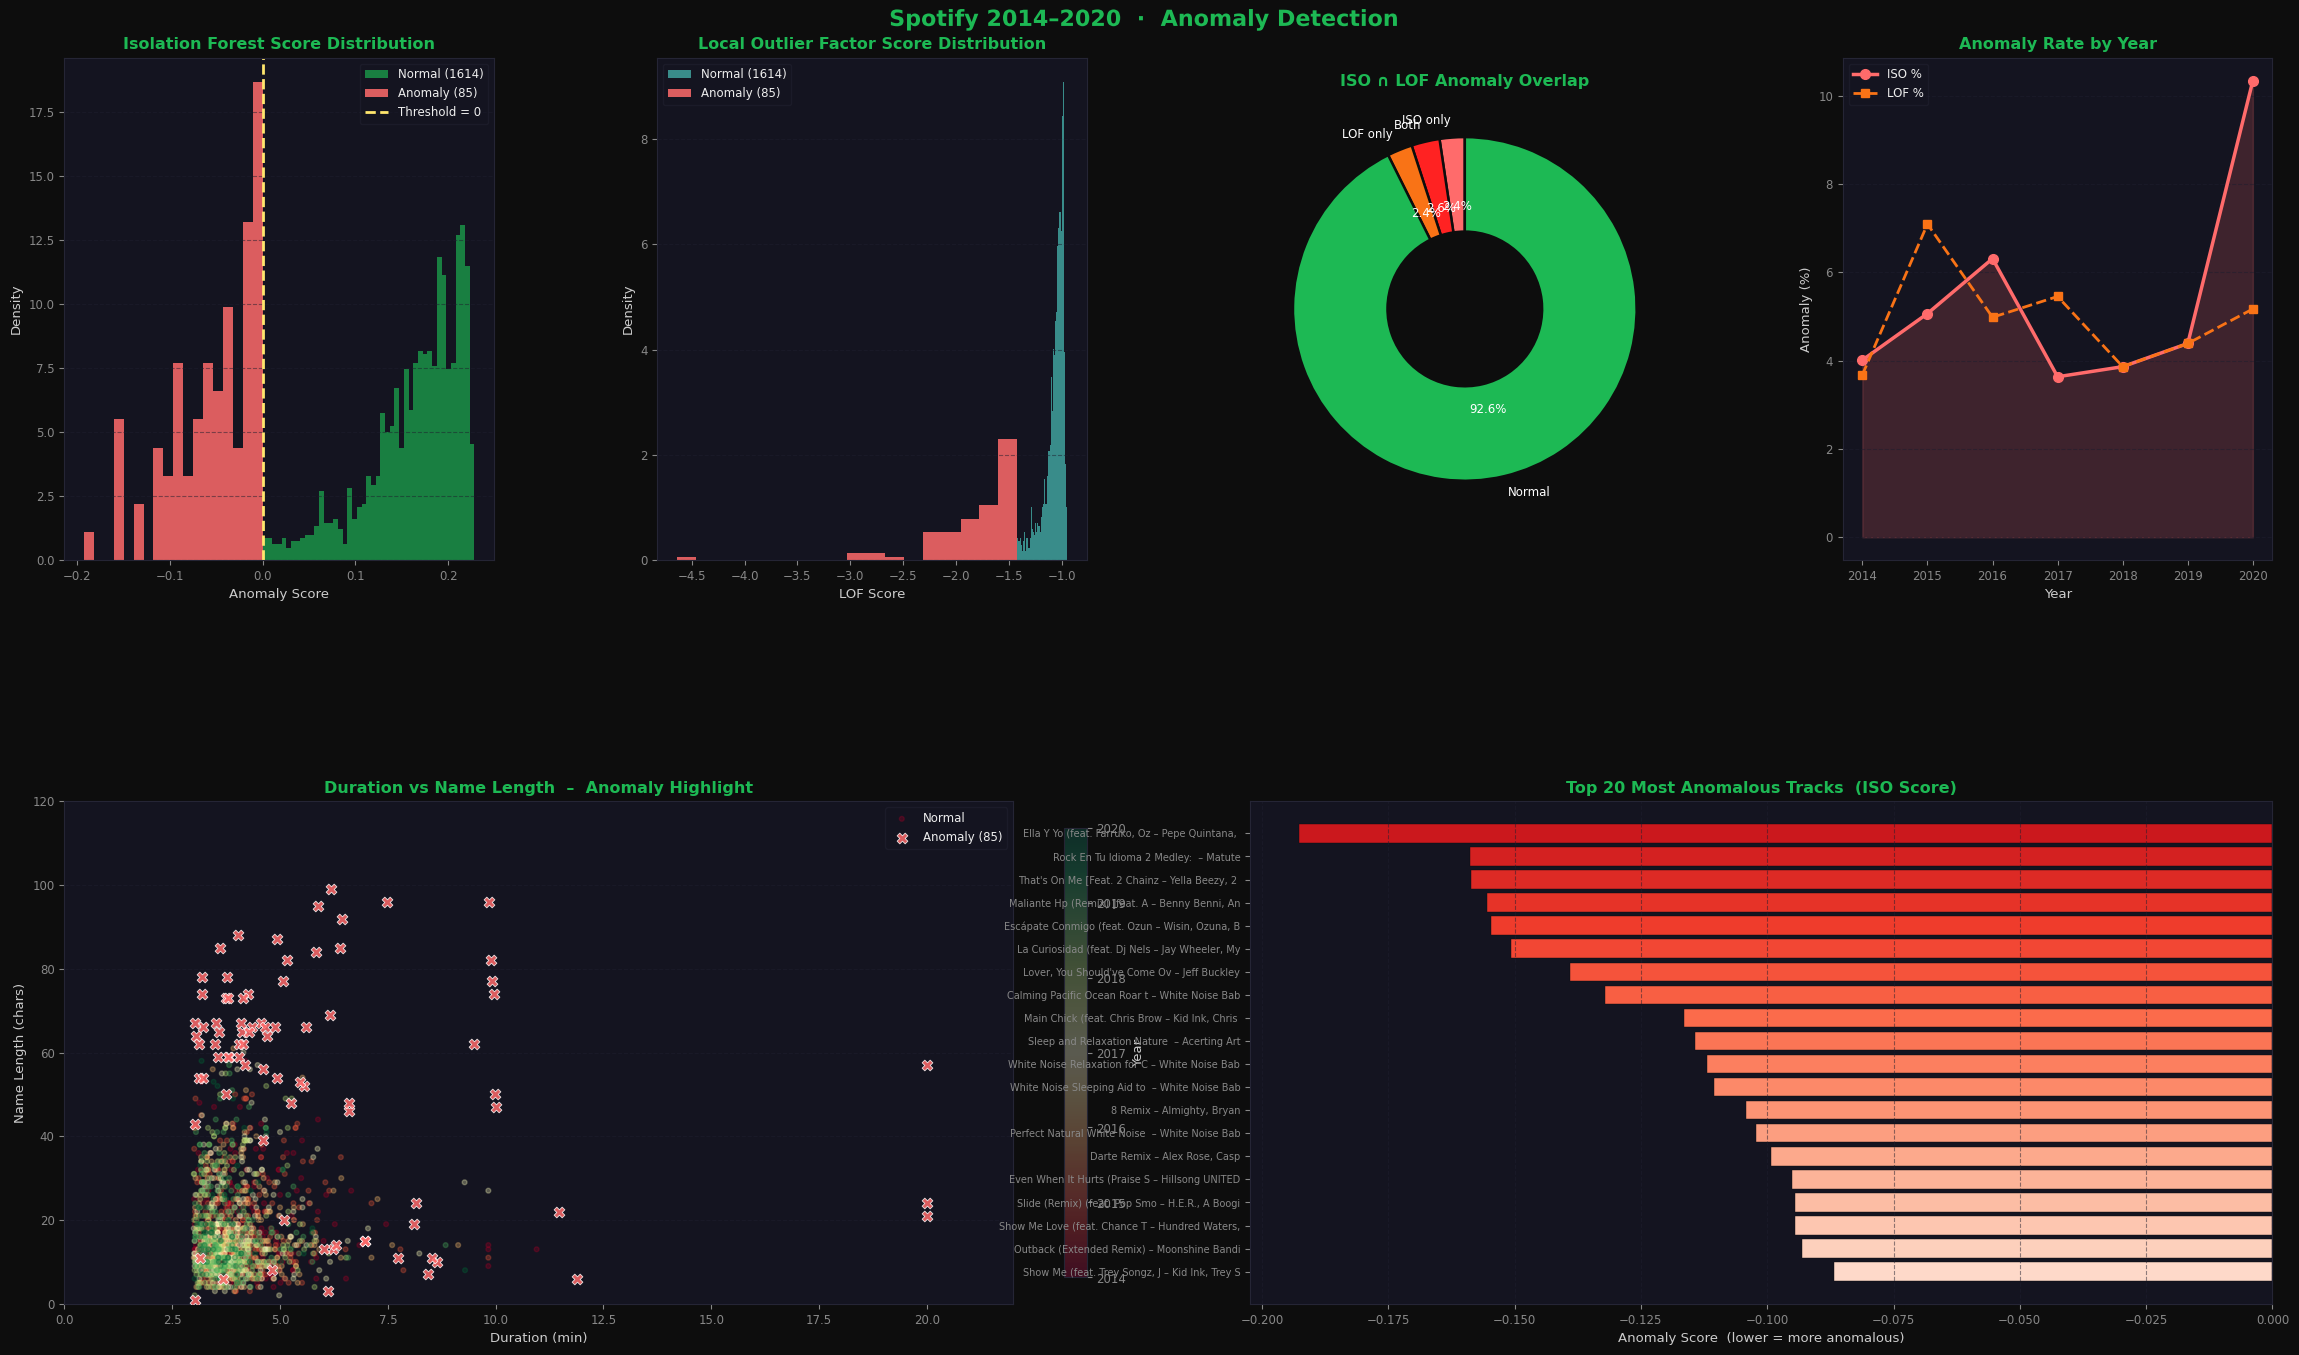

In [14]:
fig3 = plt.figure(figsize=(24, 14), facecolor=BG)
page_title(fig3, 0.977,
           "Spotify 2014–2020  ·  Anomaly Detection")
gs3 = gridspec.GridSpec(2, 4, fig3, hspace=0.48, wspace=0.38,
                         top=0.95, bottom=0.06, left=0.05, right=0.97)

X_anom   = df[["Duration_Min", "Artist_Count", "Name_Length",
                "Word_Count", "Name_Entropy"]].values
sc_anom  = StandardScaler()
Xs_anom  = sc_anom.fit_transform(X_anom)

# Isolation Forest
iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
df["ISO_Label"]  = iso.fit_predict(Xs_anom)
df["ISO_Score"]  = iso.decision_function(Xs_anom)
df["Is_Anomaly"] = (df["ISO_Label"] == -1).astype(int)

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df["LOF_Label"] = lof.fit_predict(Xs_anom)
df["LOF_Score"] = lof.negative_outlier_factor_
df["Is_LOF"]    = (df["LOF_Label"] == -1).astype(int)

n_iso  = df["Is_Anomaly"].sum()
n_lof  = df["Is_LOF"].sum()
n_both = ((df["Is_Anomaly"] == 1) & (df["Is_LOF"] == 1)).sum()
print(f"  Anomalies  ISO={n_iso}  LOF={n_lof}  Both={n_both}")

# ── 3-A  ISO score distribution
ax = fig3.add_subplot(gs3[0, 0])
style_ax(ax)
ax.hist(df.loc[df["Is_Anomaly"] == 0, "ISO_Score"],
        bins=45, density=True, color=SPOTIFY_GREEN,
        alpha=0.65, label=f"Normal ({len(df)-n_iso})")
ax.hist(df.loc[df["Is_Anomaly"] == 1, "ISO_Score"],
        bins=18, density=True, color="#FF6B6B",
        alpha=0.85, label=f"Anomaly ({n_iso})")
ax.axvline(0, color="#FFE66D", lw=2, ls="--", label="Threshold = 0")
ax.set_title("Isolation Forest Score Distribution",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Density")
ax.legend()
# ── 3-B  LOF score distribution
ax = fig3.add_subplot(gs3[0, 1])
style_ax(ax)
ax.hist(df.loc[df["Is_LOF"] == 0, "LOF_Score"],
        bins=45, density=True, color="#4ECDC4",
        alpha=0.65, label=f"Normal ({len(df)-n_lof})")
ax.hist(df.loc[df["Is_LOF"] == 1, "LOF_Score"],
        bins=18, density=True, color="#FF6B6B",
        alpha=0.85, label=f"Anomaly ({n_lof})")
ax.set_title("Local Outlier Factor Score Distribution",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("LOF Score")
ax.set_ylabel("Density")
ax.legend()

# ── 3-C  Intersection pie
ax = fig3.add_subplot(gs3[0, 2])
style_ax(ax, None)
only_iso = ((df["Is_Anomaly"] == 1) & (df["Is_LOF"] == 0)).sum()
only_lof = ((df["Is_Anomaly"] == 0) & (df["Is_LOF"] == 1)).sum()
normal   = len(df) - n_iso - only_lof
wedge_p  = dict(width=0.55, edgecolor=BG, linewidth=1.8)
ax.pie(
    [only_iso, n_both, only_lof, normal],
    labels=["ISO only", "Both", "LOF only", "Normal"],
    colors=["#FF6B6B", "#FF2222", "#F97316", SPOTIFY_GREEN],
    autopct="%1.1f%%", wedgeprops=wedge_p, startangle=90,
    textprops={"color": "white", "fontsize": 8.5},
)
ax.set_title("ISO ∩ LOF Anomaly Overlap",
             color=SPOTIFY_GREEN, fontweight="bold")

# ── 3-D  Anomaly rate by year
ax = fig3.add_subplot(gs3[0, 3])
style_ax(ax)
anom_yr = df.groupby("Year")[["Is_Anomaly", "Is_LOF"]].mean() * 100
ax.plot(anom_yr.index, anom_yr["Is_Anomaly"],
        color="#FF6B6B", lw=2.5, marker="o", ms=7, label="ISO %")
ax.plot(anom_yr.index, anom_yr["Is_LOF"],
        color="#F97316", lw=2, marker="s", ms=6, ls="--", label="LOF %")
ax.fill_between(anom_yr.index, anom_yr["Is_Anomaly"],
                alpha=0.18, color="#FF6B6B")
ax.set_title("Anomaly Rate by Year",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Anomaly (%)")
ax.legend()
# ── 3-E  Scatter: Duration vs Name Length coloured by anomaly
ax = fig3.add_subplot(gs3[1, :2])
style_ax(ax)
normal_df = df[df["Is_Anomaly"] == 0]
anomal_df = df[df["Is_Anomaly"] == 1]
sc_ = ax.scatter(normal_df["Duration_Min"], normal_df["Name_Length"],
                 c=normal_df["Year"], cmap="RdYlGn",
                 alpha=0.30, s=12, label="Normal")
ax.scatter(anomal_df["Duration_Min"], anomal_df["Name_Length"],
           color="#FF6B6B", alpha=0.85, s=60, marker="X",
           edgecolor="white", lw=0.6, zorder=6,
           label=f"Anomaly ({n_iso})")
plt.colorbar(sc_, ax=ax, label="Year", fraction=0.022)
ax.set_xlim(0, 22)
ax.set_ylim(0, 120)
ax.set_title("Duration vs Name Length  –  Anomaly Highlight",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Duration (min)")
ax.set_ylabel("Name Length (chars)")
ax.legend()

# ── 3-F  Top-20 most anomalous tracks
ax = fig3.add_subplot(gs3[1, 2:])
style_ax(ax, "x")
top_anom = (df.sort_values("ISO_Score").head(20)
              [["Track_Name", "Artists", "Duration_Min", "ISO_Score"]])
short_names = (top_anom["Track_Name"].str[:28] + " – "
               + top_anom["Artists"].str[:15]).values
clrs_ta = plt.cm.Reds_r(
    np.linspace(0.25, 0.85, len(top_anom)))
bars_ = ax.barh(range(len(top_anom)),
                top_anom["ISO_Score"].values,
                color=clrs_ta, edgecolor=BG, linewidth=0.3)
ax.set_yticks(range(len(top_anom)))
ax.set_yticklabels(short_names, fontsize=7)
ax.invert_yaxis()
ax.set_title("Top 20 Most Anomalous Tracks  (ISO Score)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Anomaly Score  (lower = more anomalous)")

fig3.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page3_anomaly.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 3 – Anomaly Detection saved")

✓  Page 4 – Time Series & Trend saved


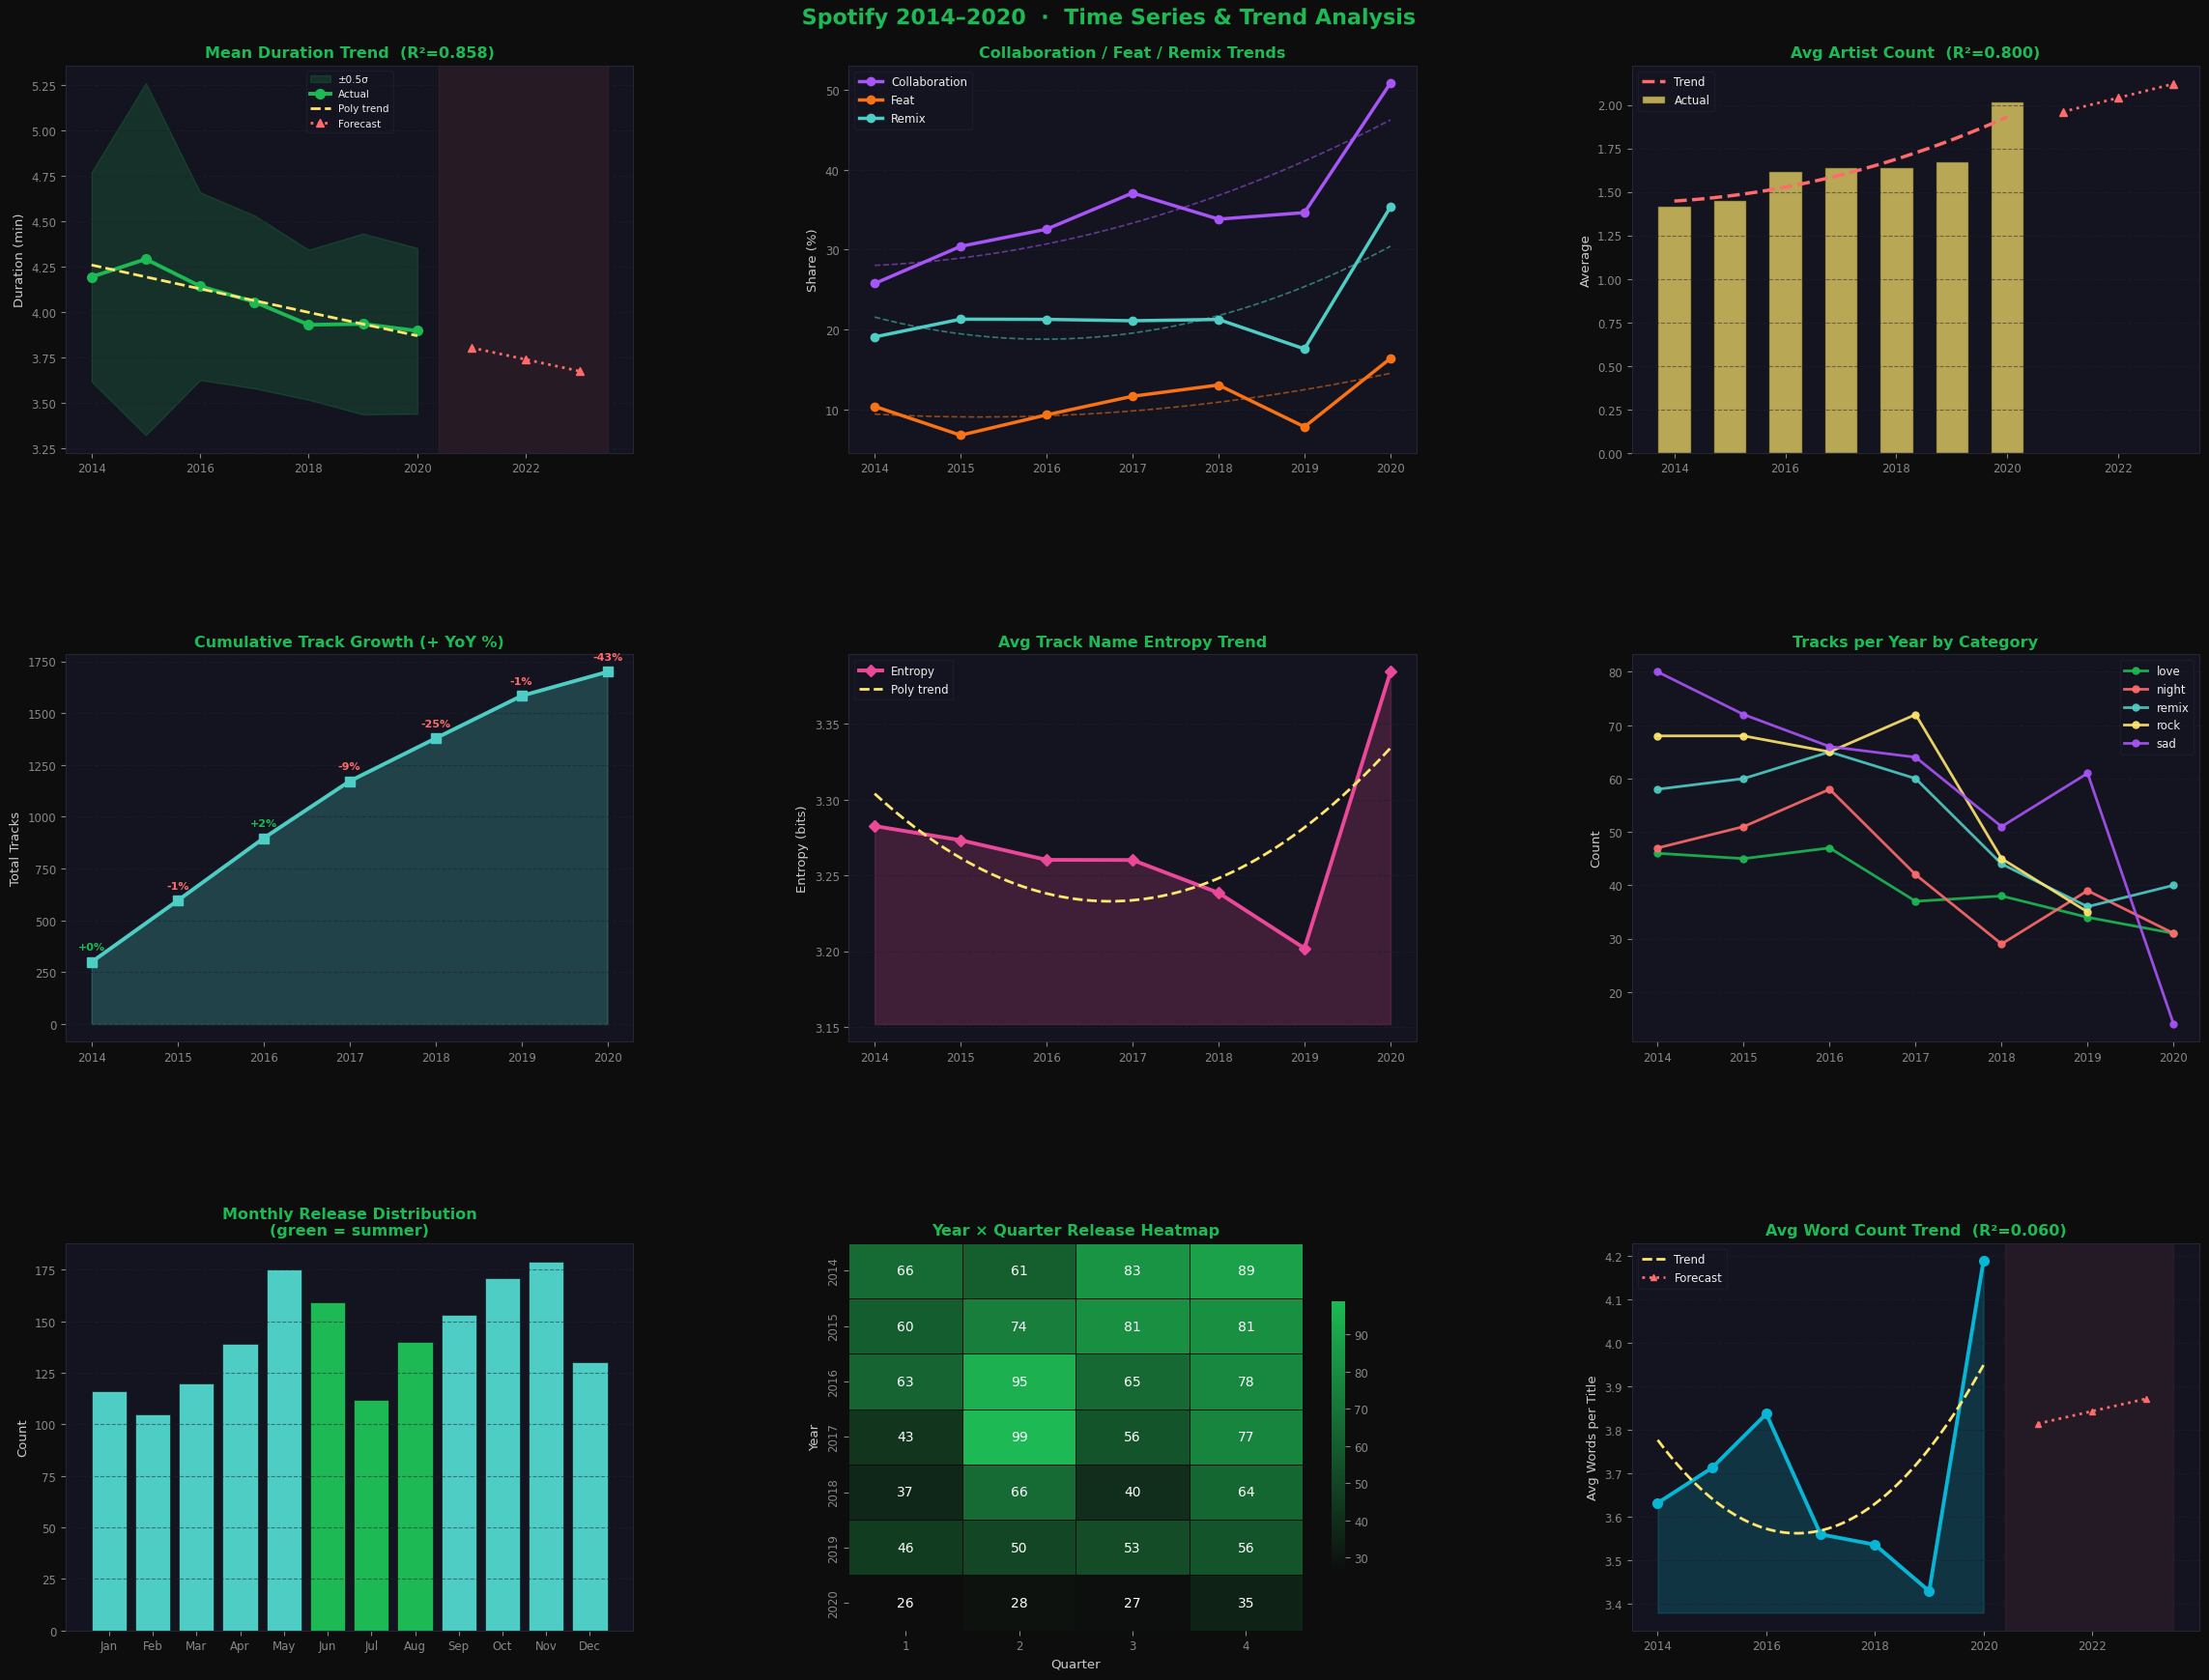

In [15]:
fig4 = plt.figure(figsize=(24, 18), facecolor=BG)
page_title(fig4, 0.977,
           "Spotify 2014–2020  ·  Time Series & Trend Analysis")
gs4 = gridspec.GridSpec(3, 3, fig4, hspace=0.52, wspace=0.38,
                         top=0.95, bottom=0.05, left=0.05, right=0.97)

yr_agg = df.groupby("Year").agg(
    count         = ("Track_ID",     "count"),
    mean_dur      = ("Duration_Min", "mean"),
    median_dur    = ("Duration_Min", "median"),
    std_dur       = ("Duration_Min", "std"),
    collab_pct    = ("Is_Collab",    "mean"),
    feat_pct      = ("Has_Feat",     "mean"),
    remix_pct     = ("Has_Remix",    "mean"),
    mean_words    = ("Word_Count",   "mean"),
    mean_artists  = ("Artist_Count", "mean"),
    entropy_avg   = ("Name_Entropy", "mean"),
).reset_index()
yrs = yr_agg["Year"].values

# ── 4-A  Mean duration + polynomial trend + forecast
ax = fig4.add_subplot(gs4[0, 0])
style_ax(ax)
y_dur = yr_agg["mean_dur"].values
xf, yf = poly_trend(yrs, y_dur)
xfut, yfut, slp, r2 = linear_forecast(yrs, y_dur, 3)
ax.fill_between(yrs,
                y_dur - yr_agg["std_dur"].values * 0.5,
                y_dur + yr_agg["std_dur"].values * 0.5,
                alpha=0.18, color=SPOTIFY_GREEN, label="±0.5σ")
ax.plot(yrs, y_dur, color=SPOTIFY_GREEN, lw=2.8,
        marker="o", ms=7, label="Actual")
ax.plot(xf,  yf,   color="#FFE66D", lw=2, ls="--", label="Poly trend")
ax.plot(xfut, yfut, color="#FF6B6B", lw=2, ls=":",
        marker="^", ms=6, label="Forecast")
ax.axvspan(yrs[-1] + 0.4, xfut[-1] + 0.5,
           alpha=0.08, color="#FF6B6B")
ax.set_title(f"Mean Duration Trend  (R²={r2:.3f})",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Duration (min)")
ax.legend(fontsize=7.5)
# ── 4-B  Collab / Feat / Remix trend
ax = fig4.add_subplot(gs4[0, 1])
style_ax(ax)
for col, lbl, c in [("collab_pct", "Collaboration", "#A855F7"),
                     ("feat_pct",   "Feat",          "#F97316"),
                     ("remix_pct",  "Remix",         "#4ECDC4")]:
    vals = yr_agg[col].values * 100
    ax.plot(yrs, vals, color=c, lw=2.5, marker="o", ms=6, label=lbl)
    xft2, yft2 = poly_trend(yrs, vals)
    ax.plot(xft2, yft2, color=c, lw=1.2, ls="--", alpha=0.55)
ax.set_title("Collaboration / Feat / Remix Trends",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Share (%)")
ax.legend()

# ── 4-C  Average artist count + forecast
ax = fig4.add_subplot(gs4[0, 2])
style_ax(ax)
y_art = yr_agg["mean_artists"].values
xfa, yfa = poly_trend(yrs, y_art)
xfuta, yfuta, _, r2a = linear_forecast(yrs, y_art, 3)
ax.bar(yrs, y_art, color=PALETTE[3], alpha=0.7,
       width=0.6, edgecolor=BG, label="Actual")
ax.plot(xfa,   yfa,   color="#FF6B6B", lw=2.5, ls="--", label="Trend")
ax.plot(xfuta, yfuta, color="#FF6B6B", lw=2,   ls=":",
        marker="^", ms=6)
ax.set_title(f"Avg Artist Count  (R²={r2a:.3f})",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Average")
ax.legend()

# ── 4-D  Cumulative count + YoY growth %
ax = fig4.add_subplot(gs4[1, 0])
style_ax(ax)
cumul = yr_agg["count"].cumsum().values
yoy   = np.concatenate([[0], np.diff(yr_agg["count"].values)
                         / yr_agg["count"].values[:-1] * 100])
ax.fill_between(yrs, cumul, alpha=0.25, color="#4ECDC4")
ax.plot(yrs, cumul, color="#4ECDC4", lw=2.8, marker="s", ms=7)
for x, y, g in zip(yrs, cumul, yoy):
    col = SPOTIFY_GREEN if g >= 0 else "#FF6B6B"
    ax.annotate(f"{g:+.0f}%", (x, y),
                xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=8, color=col, fontweight="bold")
ax.set_title("Cumulative Track Growth (+ YoY %)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Total Tracks")
# ── 4-E  Name entropy trend
ax = fig4.add_subplot(gs4[1, 1])
style_ax(ax)
y_ent = yr_agg["entropy_avg"].values
xfe, yfe = poly_trend(yrs, y_ent)
ax.plot(yrs, y_ent, color="#EC4899", lw=2.8,
        marker="D", ms=6, label="Entropy")
ax.fill_between(yrs, y_ent, y_ent.min() - 0.05,
                alpha=0.2, color="#EC4899")
ax.plot(xfe, yfe, color="#FFE66D", lw=2, ls="--", label="Poly trend")
ax.set_title("Avg Track Name Entropy Trend",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Entropy (bits)")
ax.legend()

# ── 4-F  Per-category yearly tracks
ax = fig4.add_subplot(gs4[1, 2])
style_ax(ax)
for i, q in enumerate(le.classes_):
    qyr = df[df["Query"] == q].groupby("Year").size()
    ax.plot(qyr.index, qyr.values, color=PALETTE[i], lw=2,
            marker="o", ms=5, label=q, alpha=0.9)
ax.set_title("Tracks per Year by Category",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Count")
ax.legend()

# ── 4-G  Monthly release distribution
ax = fig4.add_subplot(gs4[2, 0])
style_ax(ax)
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
mc = df["Release_Month"].value_counts().sort_index()
mc_full = pd.Series(0, index=range(1, 13))
mc_full.update(mc)
summer_clr = [PALETTE[0] if m in [6, 7, 8] else "#4ECDC4"
              for m in range(1, 13)]
ax.bar(range(1, 13), mc_full.values, color=summer_clr,
       edgecolor=BG, linewidth=0.4)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES, fontsize=8.5)
ax.set_title("Monthly Release Distribution\n(green = summer)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Count")
# ── 4-H  Year × Quarter heatmap
ax = fig4.add_subplot(gs4[2, 1])
style_ax(ax, None)
qy = df.groupby(["Year", "Release_Quarter"]).size().unstack(fill_value=0)
sns.heatmap(qy, ax=ax, cmap=GREEN_CMAP, annot=True, fmt="d",
            annot_kws={"size": 10}, linewidths=0.4, linecolor=BG,
            cbar_kws={"shrink": 0.7})
ax.set_title("Year × Quarter Release Heatmap",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Year")

# ── 4-I  Word count forecast
ax = fig4.add_subplot(gs4[2, 2])
style_ax(ax)
y_wc = yr_agg["mean_words"].values
xfw, yfw     = poly_trend(yrs, y_wc)
xfutw, yfutw, _, r2w = linear_forecast(yrs, y_wc, 3)
ax.plot(yrs,   y_wc,  color="#06B6D4", lw=2.8, marker="o", ms=7)
ax.fill_between(yrs, y_wc, y_wc.min() - 0.05,
                alpha=0.2, color="#06B6D4")
ax.plot(xfw,   yfw,   color="#FFE66D", lw=2, ls="--", label="Trend")
ax.plot(xfutw, yfutw, color="#FF6B6B", lw=2, ls=":",
        marker="^", ms=5, label="Forecast")
ax.axvspan(yrs[-1] + 0.4, xfutw[-1] + 0.5,
           alpha=0.07, color="#FF6B6B")
ax.set_title(f"Avg Word Count Trend  (R²={r2w:.3f})",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Avg Words per Title")
ax.legend()

fig4.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page4_timeseries.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 4 – Time Series & Trend saved")


  Network  nodes=881  edges=1612
  Subgraph nodes=40  edges=245
✓  Page 5 – Artist Network saved


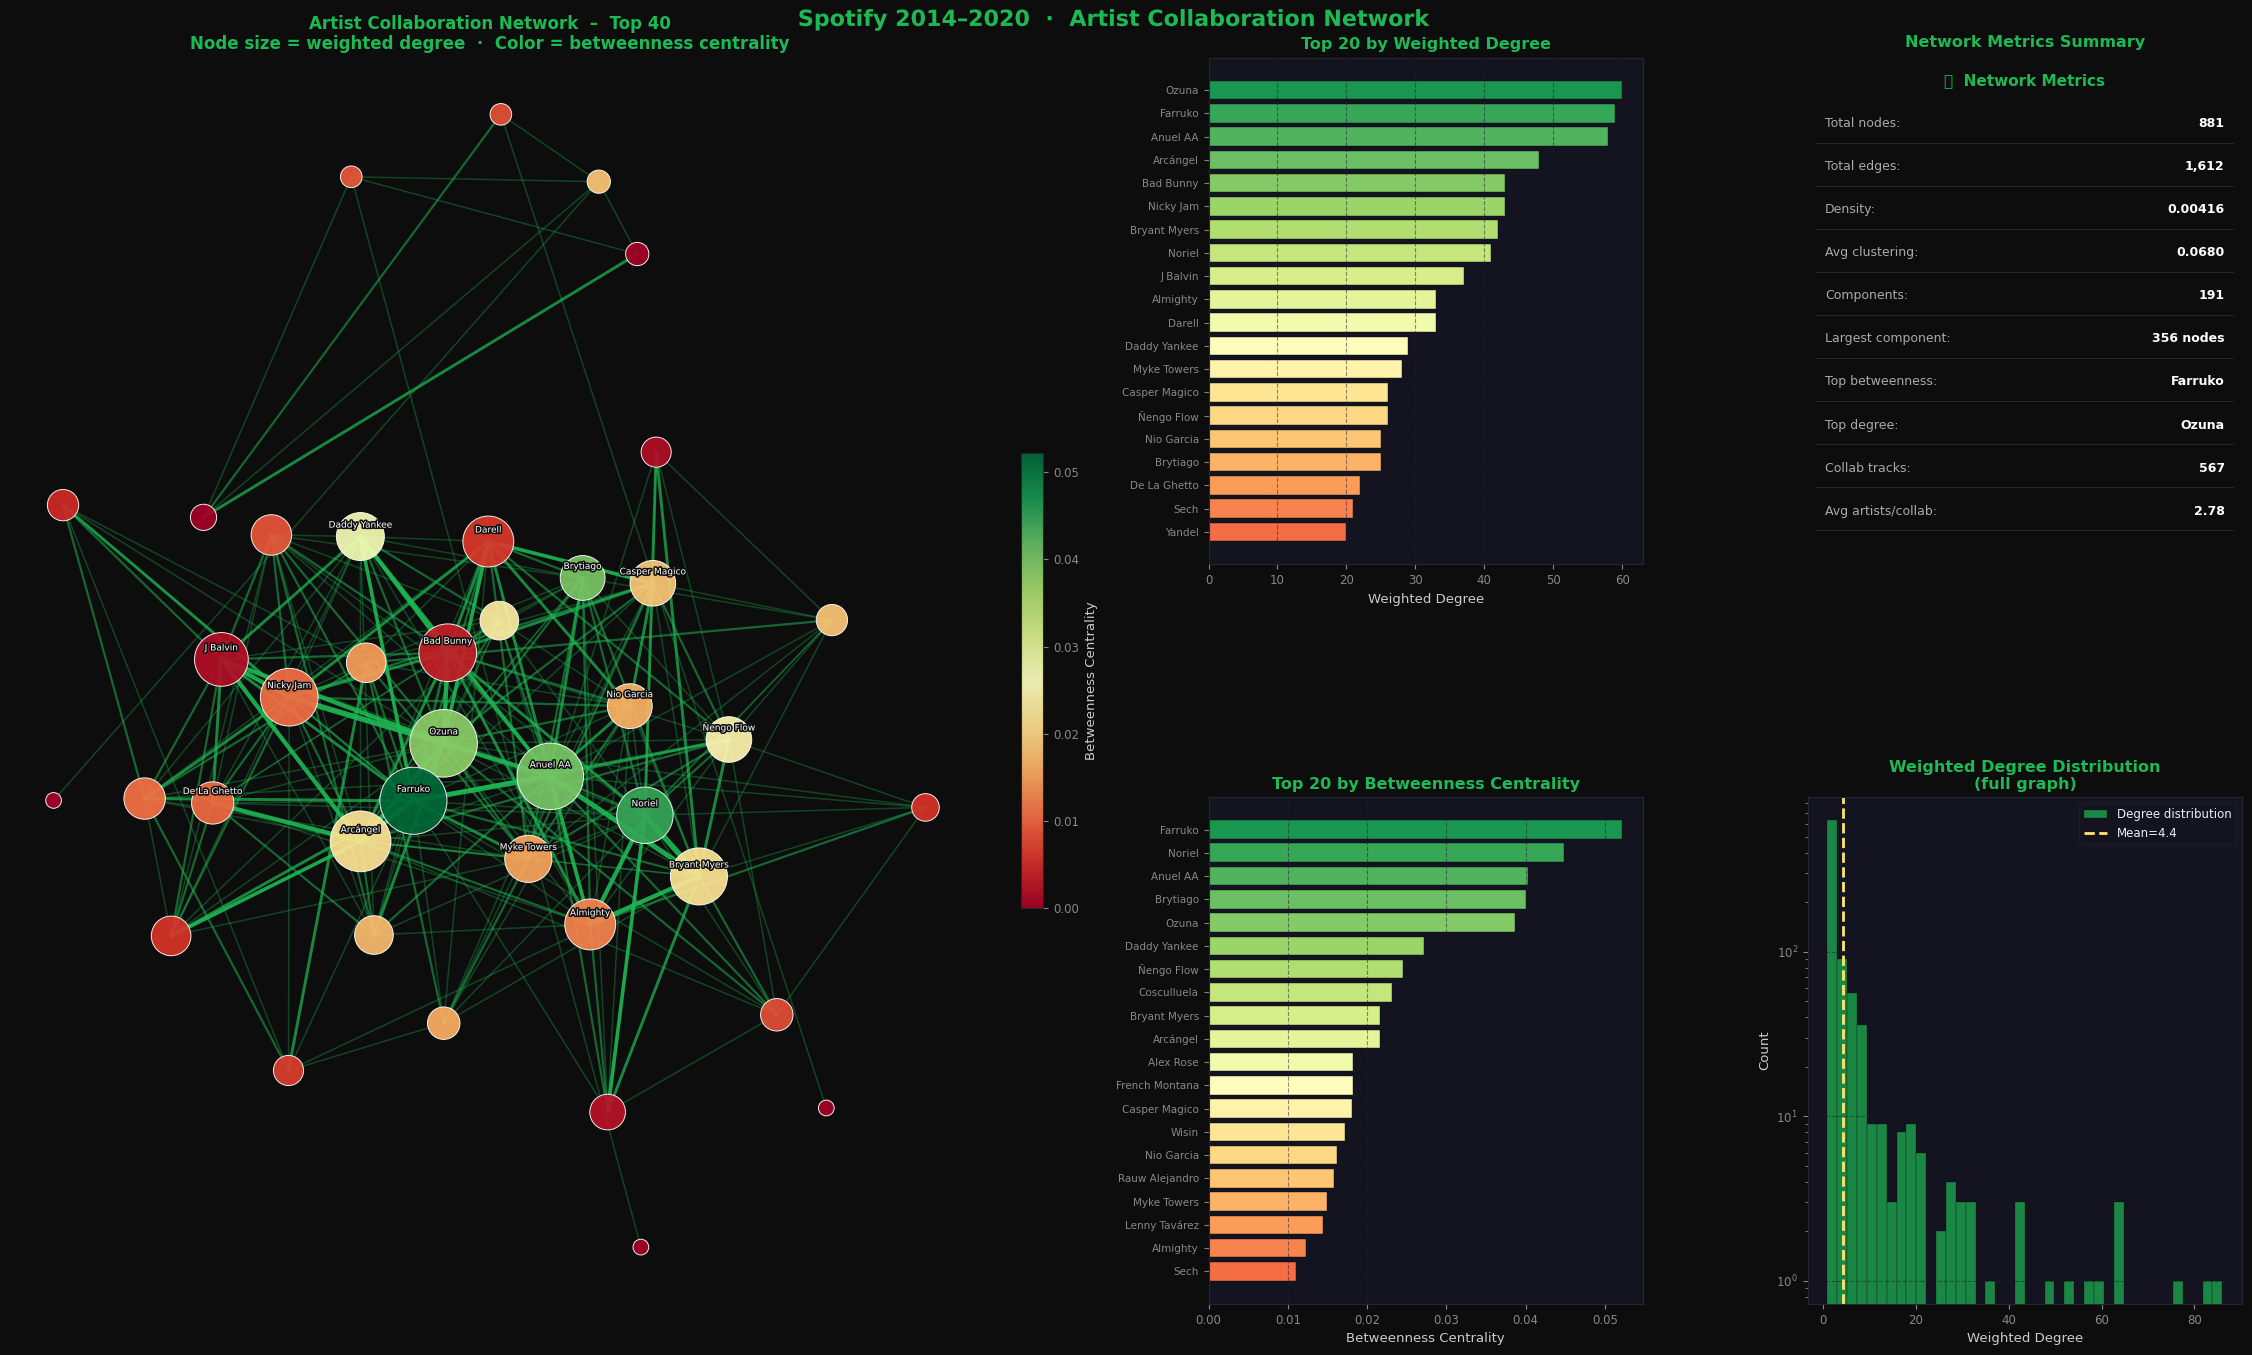

In [16]:
fig5 = plt.figure(figsize=(24, 14), facecolor=BG)
page_title(fig5, 0.977,
           "Spotify 2014–2020  ·  Artist Collaboration Network")
gs5 = gridspec.GridSpec(2, 4, fig5, hspace=0.46, wspace=0.38,
                         top=0.95, bottom=0.06, left=0.04, right=0.97)

# Build graph
G = nx.Graph()
for artists_str in df[df["Artist_Count"] > 1]["Artists"]:
    members = [a.strip() for a in str(artists_str).split(",")
               if len(a.strip()) > 1]
    for i in range(len(members)):
        for j in range(i + 1, len(members)):
            a1, a2 = members[i], members[j]
            if G.has_edge(a1, a2):
                G[a1][a2]["weight"] += 1
            else:
                G.add_edge(a1, a2, weight=1)

degree_w = dict(G.degree(weight="weight"))
TOP_N    = 40
top_art  = sorted(degree_w, key=degree_w.get, reverse=True)[:TOP_N]
H        = G.subgraph(top_art).copy()
print(f"  Network  nodes={G.number_of_nodes()}  edges={G.number_of_edges()}")
print(f"  Subgraph nodes={H.number_of_nodes()}  edges={H.number_of_edges()}")

betw   = nx.betweenness_centrality(H, weight="weight")
closn  = nx.closeness_centrality(H)
deg_h  = dict(H.degree(weight="weight"))
pos    = nx.spring_layout(H, seed=42, k=2.4, iterations=90)

# ── 5-A  Main network (spans 2 rows × 2 cols)
ax_net = fig5.add_subplot(gs5[:, :2])
ax_net.set_facecolor(CARD)
for sp in ax_net.spines.values():
    sp.set_edgecolor("#252535")

for u, v in H.edges():
    w = H[u][v]["weight"]
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax_net.plot([x0, x1], [y0, y1],
                color=SPOTIFY_GREEN,
                alpha=min(0.9, 0.12 + w * 0.2),
                linewidth=min(4, 0.6 + w * 0.5),
                zorder=1)

node_sz  = [deg_h[n] * 38 + 90 for n in H.nodes()]
node_col = [betw[n] for n in H.nodes()]
sc5 = ax_net.scatter(
    [pos[n][0] for n in H.nodes()],
    [pos[n][1] for n in H.nodes()],
    s=node_sz, c=node_col, cmap="RdYlGn",
    vmin=0, vmax=max(node_col),
    edgecolors="white", linewidths=0.7,
    alpha=0.92, zorder=3)
plt.colorbar(sc5, ax=ax_net, label="Betweenness Centrality",
             fraction=0.022, shrink=0.65)
top_label = sorted(deg_h, key=deg_h.get, reverse=True)[:18]
for node in H.nodes():
    if node in top_label:
        ax_net.annotate(
            node, pos[node], fontsize=6.5, color="white",
            ha="center", va="bottom",
            xytext=(0, 5), textcoords="offset points",
            path_effects=[pe.withStroke(linewidth=2.2, foreground=BG)])

ax_net.set_title(
    f"Artist Collaboration Network  –  Top {TOP_N}\n"
    "Node size = weighted degree  ·  Color = betweenness centrality",
    color=SPOTIFY_GREEN, fontweight="bold", fontsize=12)
ax_net.axis("off")

# ── 5-B  Top-20 weighted degree
ax = fig5.add_subplot(gs5[0, 2])
style_ax(ax, "x")
top20_d  = sorted(deg_h, key=deg_h.get, reverse=True)[:20]
top20_v  = [deg_h[a] for a in top20_d]
short20  = [a[:16] + "…" if len(a) > 16 else a for a in top20_d]
clrs_20  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 20))
ax.barh(range(20), top20_v[::-1],
        color=clrs_20, edgecolor=BG, linewidth=0.3)
ax.set_yticks(range(20))
ax.set_yticklabels(short20[::-1], fontsize=7.5)
ax.set_title("Top 20 by Weighted Degree",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Weighted Degree")

# ── 5-C  Top-20 betweenness centrality
ax = fig5.add_subplot(gs5[1, 2])
style_ax(ax, "x")
top20_b  = sorted(betw, key=betw.get, reverse=True)[:20]
top20_bv = [betw[a] for a in top20_b]
short20b = [a[:16] + "…" if len(a) > 16 else a for a in top20_b]
clrs_20b = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 20))
ax.barh(range(20), top20_bv[::-1],
        color=clrs_20b, edgecolor=BG, linewidth=0.3)
ax.set_yticks(range(20))
ax.set_yticklabels(short20b[::-1], fontsize=7.5)
ax.set_title("Top 20 by Betweenness Centrality",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Betweenness Centrality")
# ── 5-D  Network metrics card
ax = fig5.add_subplot(gs5[0, 3])
style_ax(ax, None); ax.axis("off")

gcc  = G.subgraph(max(nx.connected_components(G), key=len))
dens = nx.density(G)
avg_clust = nx.average_clustering(G, weight="weight")
comps     = nx.number_connected_components(G)

metrics5 = [
    ("Total nodes",        f"{G.number_of_nodes():,}"),
    ("Total edges",        f"{G.number_of_edges():,}"),
    ("Density",            f"{dens:.5f}"),
    ("Avg clustering",     f"{avg_clust:.4f}"),
    ("Components",         str(comps)),
    ("Largest component",  f"{len(gcc):,} nodes"),
    ("Top betweenness",    top20_b[0][:20]),
    ("Top degree",         top20_d[0][:20]),
    ("Collab tracks",      str(df["Is_Collab"].sum())),
    ("Avg artists/collab", f"{df[df['Is_Collab']==1]['Artist_Count'].mean():.2f}"),
]
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.5, 0.97, "🌐  Network Metrics",
        ha="center", va="top", fontsize=11, fontweight="bold",
        color=SPOTIFY_GREEN, transform=ax.transAxes)
for i, (k, v) in enumerate(metrics5):
    yp = 0.87 - i * 0.085
    ax.text(0.04, yp, k + ":", ha="left", va="center",
            fontsize=9, color="#AAAAAA", transform=ax.transAxes)
    ax.text(0.96, yp, v,  ha="right", va="center",
            fontsize=9, color="white", fontweight="bold",
            transform=ax.transAxes)
    ln = Line2D([0.02, 0.98], [yp - 0.038, yp - 0.038],
                color="#252535", lw=0.7, transform=ax.transAxes)
    ax.add_line(ln)
ax.set_title("Network Metrics Summary",
             color=SPOTIFY_GREEN, fontweight="bold", pad=8)

# ── 5-E  Degree distribution histogram
ax = fig5.add_subplot(gs5[1, 3])
style_ax(ax)
all_deg = [d for _, d in G.degree(weight="weight")]
ax.hist(all_deg, bins=40, color=SPOTIFY_GREEN,
        alpha=0.7, edgecolor=BG, linewidth=0.3,
        label="Degree distribution")
ax.axvline(np.mean(all_deg), color="#FFE66D", lw=2,
           ls="--", label=f"Mean={np.mean(all_deg):.1f}")
ax.set_title("Weighted Degree Distribution\n(full graph)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Weighted Degree")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.legend()

fig5.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page5_network.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 5 – Artist Network saved")

✓  Page 6 – Clustering & PCA saved


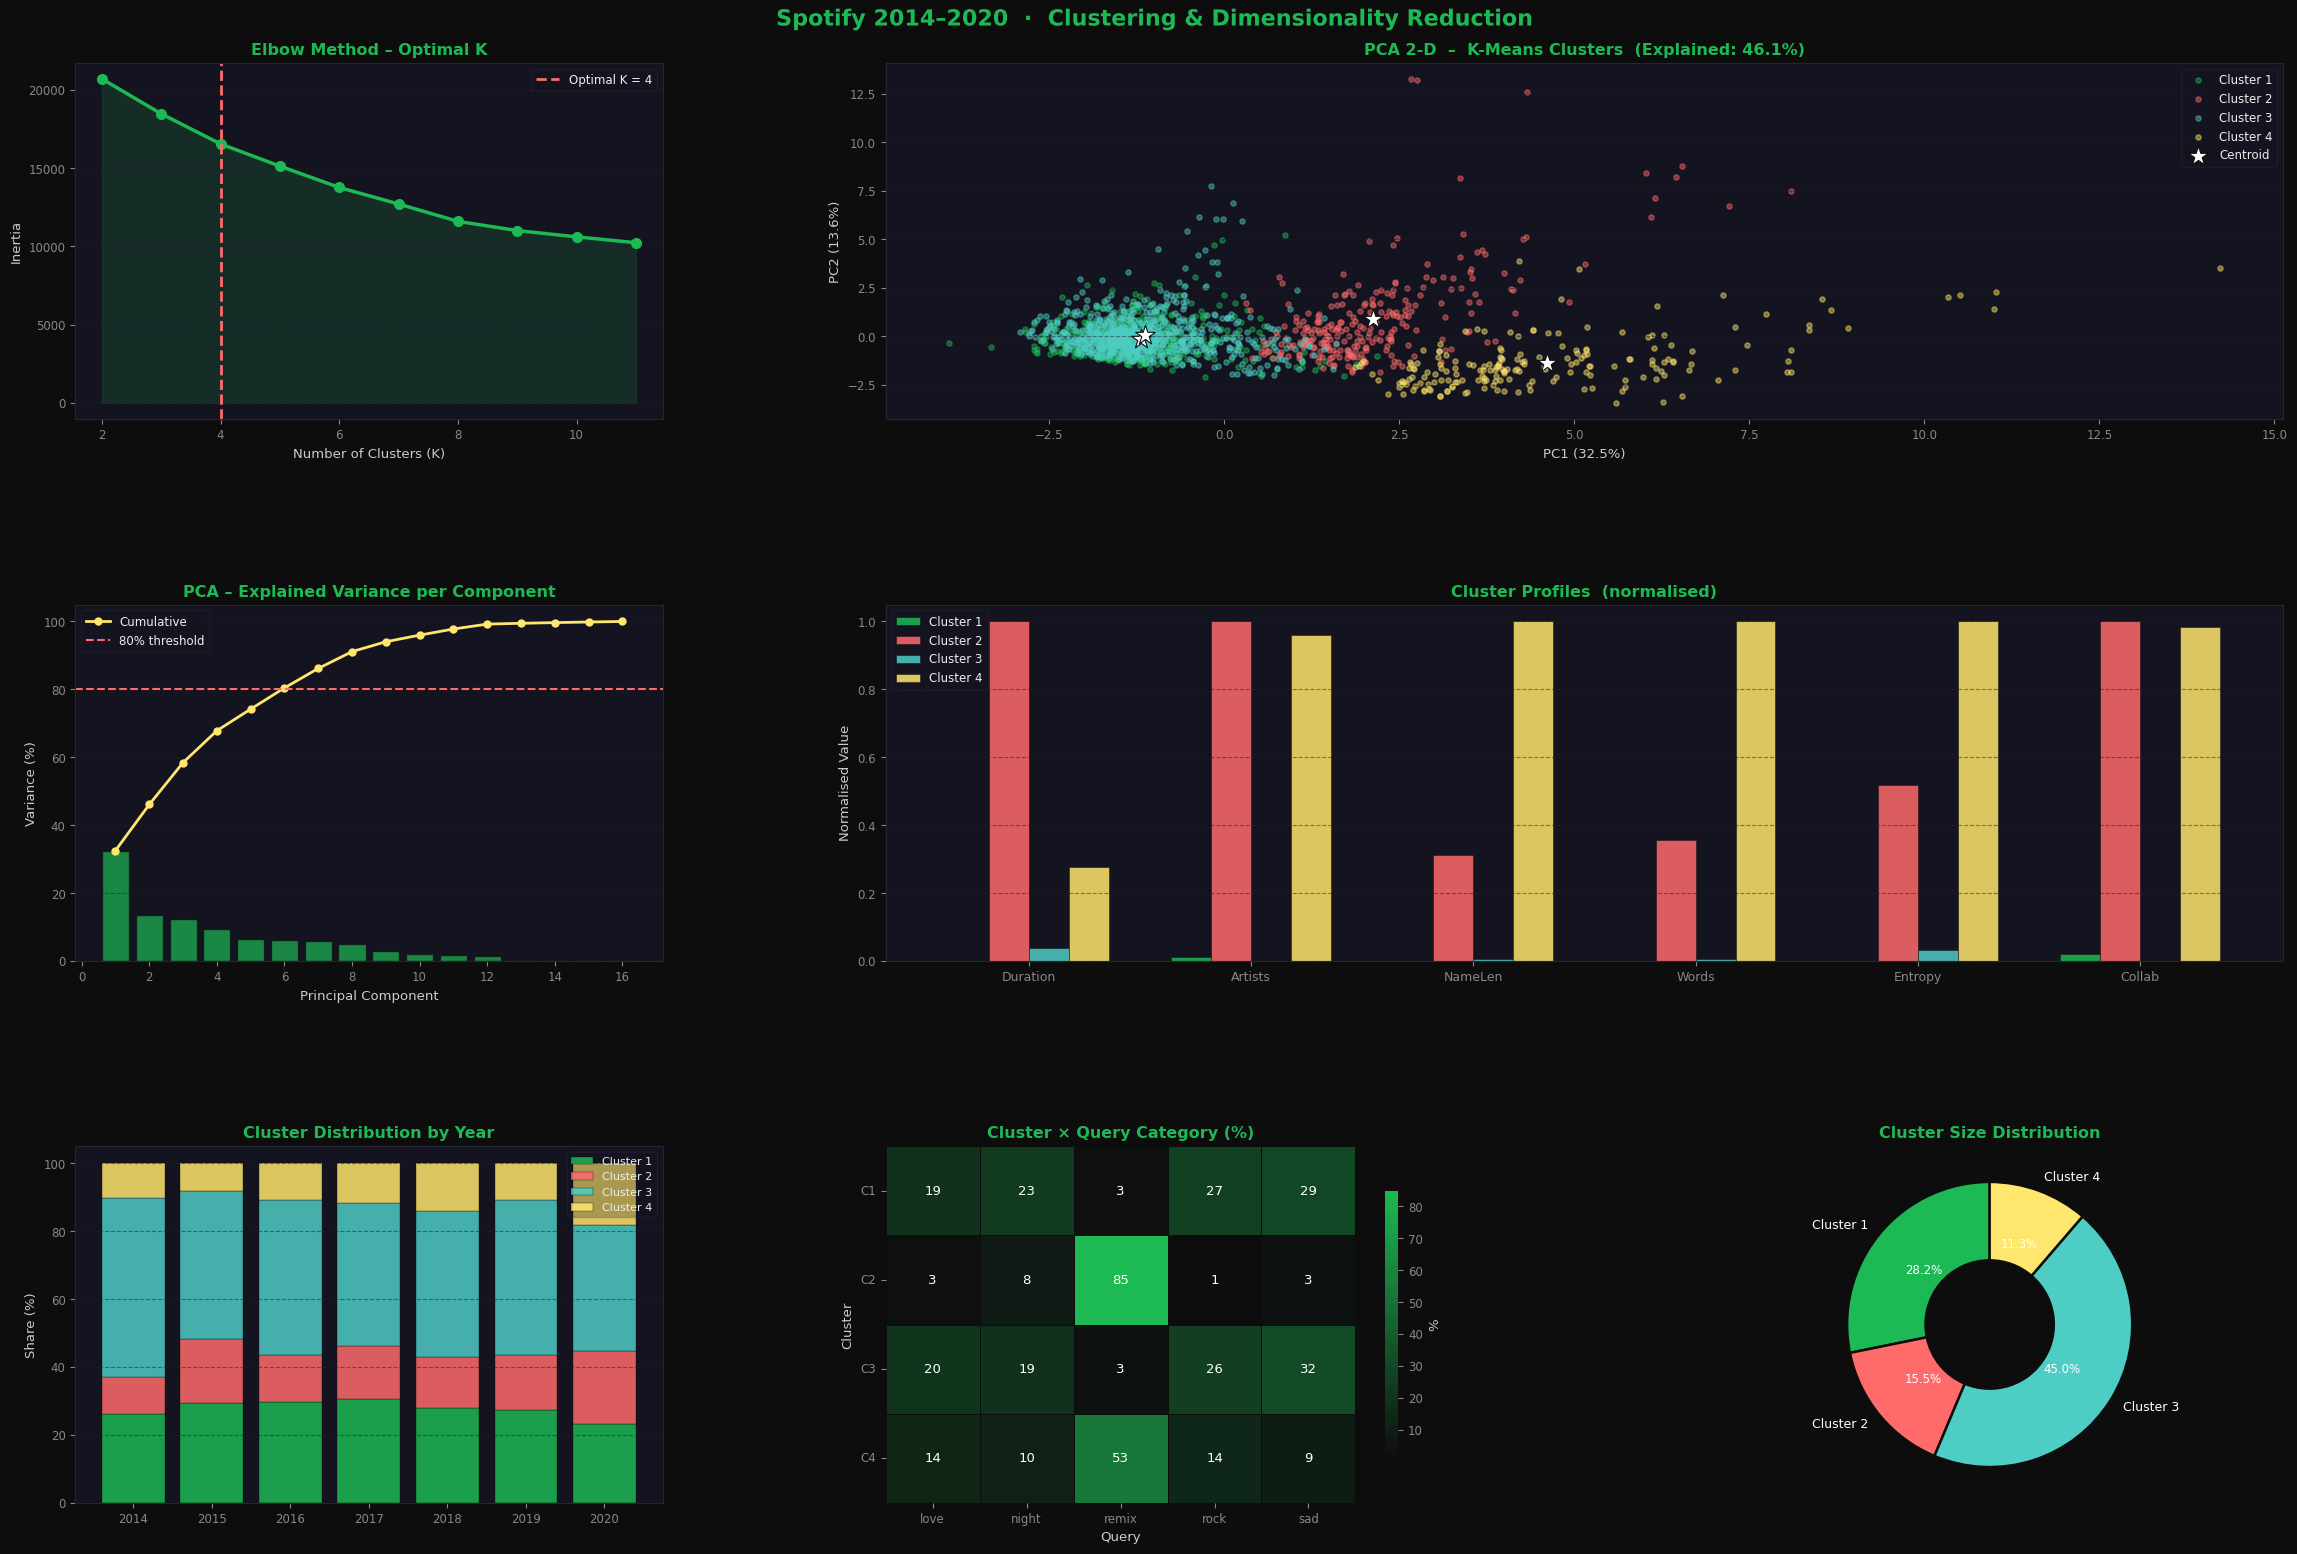

In [17]:
fig6 = plt.figure(figsize=(24, 16), facecolor=BG)
page_title(fig6, 0.977,
           "Spotify 2014–2020  ·  Clustering & Dimensionality Reduction")
gs6 = gridspec.GridSpec(3, 3, fig6, hspace=0.52, wspace=0.38,
                         top=0.95, bottom=0.05, left=0.05, right=0.97)

X_cl  = df[FEATURE_COLS].values
sc_cl = StandardScaler()
Xs_cl = sc_cl.fit_transform(X_cl)

# ── Elbow curve
ax = fig6.add_subplot(gs6[0, 0])
style_ax(ax)
inertias = []
K_RANGE  = range(2, 12)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs_cl)
    inertias.append(km.inertia_)
ax.plot(list(K_RANGE), inertias, color=SPOTIFY_GREEN, lw=2.5,
        marker="o", ms=7)
ax.fill_between(list(K_RANGE), inertias, alpha=0.15, color=SPOTIFY_GREEN)
ax.axvline(4, color="#FF6B6B", lw=2, ls="--", label="Optimal K = 4")
ax.set_title("Elbow Method – Optimal K", color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia")
ax.legend()

# Final clustering
BEST_K  = 4
km_fin  = KMeans(n_clusters=BEST_K, random_state=42, n_init=15)
df["Cluster"] = km_fin.fit_predict(Xs_cl)

# PCA 2-D & 3-D (project)
pca2  = PCA(n_components=2, random_state=42)
pca3  = PCA(n_components=3, random_state=42)
Xp2   = pca2.fit_transform(Xs_cl)
Xp3   = pca3.fit_transform(Xs_cl)
df["PC1"] = Xp2[:, 0]
df["PC2"] = Xp2[:, 1]

# ── PCA 2-D scatter coloured by cluster
ax = fig6.add_subplot(gs6[0, 1:])
style_ax(ax)
for c in range(BEST_K):
    m = df["Cluster"] == c
    ax.scatter(df.loc[m, "PC1"], df.loc[m, "PC2"],
               color=PALETTE[c], alpha=0.45, s=14, label=f"Cluster {c+1}")
centers_pca = pca2.transform(km_fin.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           color="white", s=220, marker="*", zorder=6,
           edgecolor=BG, lw=0.8, label="Centroid")
ax.set_title(f"PCA 2-D  –  K-Means Clusters  "
             f"(Explained: {pca2.explained_variance_ratio_.sum()*100:.1f}%)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend()
# ── PCA explained variance
ax = fig6.add_subplot(gs6[1, 0])
style_ax(ax)
pca_full = PCA(random_state=42)
pca_full.fit(Xs_cl)
ev_ratio = pca_full.explained_variance_ratio_
ev_cum   = np.cumsum(ev_ratio)
ax.bar(range(1, len(ev_ratio) + 1), ev_ratio * 100,
       color=SPOTIFY_GREEN, alpha=0.7, edgecolor=BG)
ax.plot(range(1, len(ev_cum) + 1), ev_cum * 100,
        color="#FFE66D", lw=2, marker="o", ms=5, label="Cumulative")
ax.axhline(80, color="#FF6B6B", lw=1.5, ls="--", label="80% threshold")
ax.set_title("PCA – Explained Variance per Component",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance (%)")
ax.legend()

# ── Cluster profile (normalised)
ax = fig6.add_subplot(gs6[1, 1:])
style_ax(ax)
profile_cols = ["Duration_Min", "Artist_Count", "Name_Length",
                "Word_Count", "Name_Entropy", "Is_Collab"]
profile = df.groupby("Cluster")[profile_cols].mean()
profile_n = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
x_pr  = np.arange(len(profile_cols))
width = 0.18
for i, (idx, row) in enumerate(profile_n.iterrows()):
    ax.bar(x_pr + i * width, row.values, width=width,
           color=PALETTE[i], label=f"Cluster {idx+1}",
           alpha=0.85, edgecolor=BG, linewidth=0.4)
ax.set_xticks(x_pr + width * (BEST_K - 1) / 2)
ax.set_xticklabels(["Duration", "Artists", "NameLen",
                     "Words", "Entropy", "Collab"],
                   fontsize=9)
ax.set_title("Cluster Profiles  (normalised)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Normalised Value")
ax.legend()

# ── Cluster × Year stacked bar
ax = fig6.add_subplot(gs6[2, 0])
style_ax(ax)
cy = df.groupby(["Year", "Cluster"]).size().unstack(fill_value=0)
cy_pct = cy.div(cy.sum(axis=1), axis=0) * 100
bot = np.zeros(len(cy_pct))
for c in range(BEST_K):
    if c in cy_pct.columns:
        ax.bar(cy_pct.index, cy_pct[c], bottom=bot,
               color=PALETTE[c], label=f"Cluster {c+1}",
               alpha=0.85, edgecolor=BG, linewidth=0.3)
        bot += cy_pct[c].values
ax.set_title("Cluster Distribution by Year",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Share (%)")
ax.legend(fontsize=8)
# ── Cluster × Category heatmap
ax = fig6.add_subplot(gs6[2, 1])
style_ax(ax, None)
cq = df.groupby(["Cluster", "Query"]).size().unstack(fill_value=0)
cq_pct = cq.div(cq.sum(axis=1), axis=0) * 100
sns.heatmap(cq_pct, ax=ax, cmap=GREEN_CMAP, annot=True, fmt=".0f",
            annot_kws={"size": 9.5}, linewidths=0.4, linecolor=BG,
            cbar_kws={"shrink": 0.75, "label": "%"})
ax.set_title("Cluster × Query Category (%)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Query")
ax.set_ylabel("Cluster")
ax.set_yticklabels([f"C{i+1}" for i in range(BEST_K)], rotation=0)

# ── Cluster size pie
ax = fig6.add_subplot(gs6[2, 2])
style_ax(ax, None)
sizes = df["Cluster"].value_counts().sort_index()
wp    = dict(width=0.55, edgecolor=BG, linewidth=1.8)
wedges_, texts_, at_ = ax.pie(
    sizes.values,
    labels=[f"Cluster {i+1}" for i in sizes.index],
    colors=PALETTE[:BEST_K],
    autopct="%1.1f%%", wedgeprops=wp, startangle=90,
    textprops={"color": "white", "fontsize": 9},
)
for a in at_: a.set_fontsize(8.5)
ax.set_title("Cluster Size Distribution",
             color=SPOTIFY_GREEN, fontweight="bold")

fig6.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page6_clustering.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 6 – Clustering & PCA saved")


  Random Forest         Acc=0.485  CV=0.470±0.018
  Gradient Boost        Acc=0.455  CV=0.465±0.015
  Logistic Reg          Acc=0.448  CV=0.436±0.025
  Voting Ensemble       Acc=0.493  CV=0.478±0.019
✓  Page 7 – Machine Learning saved


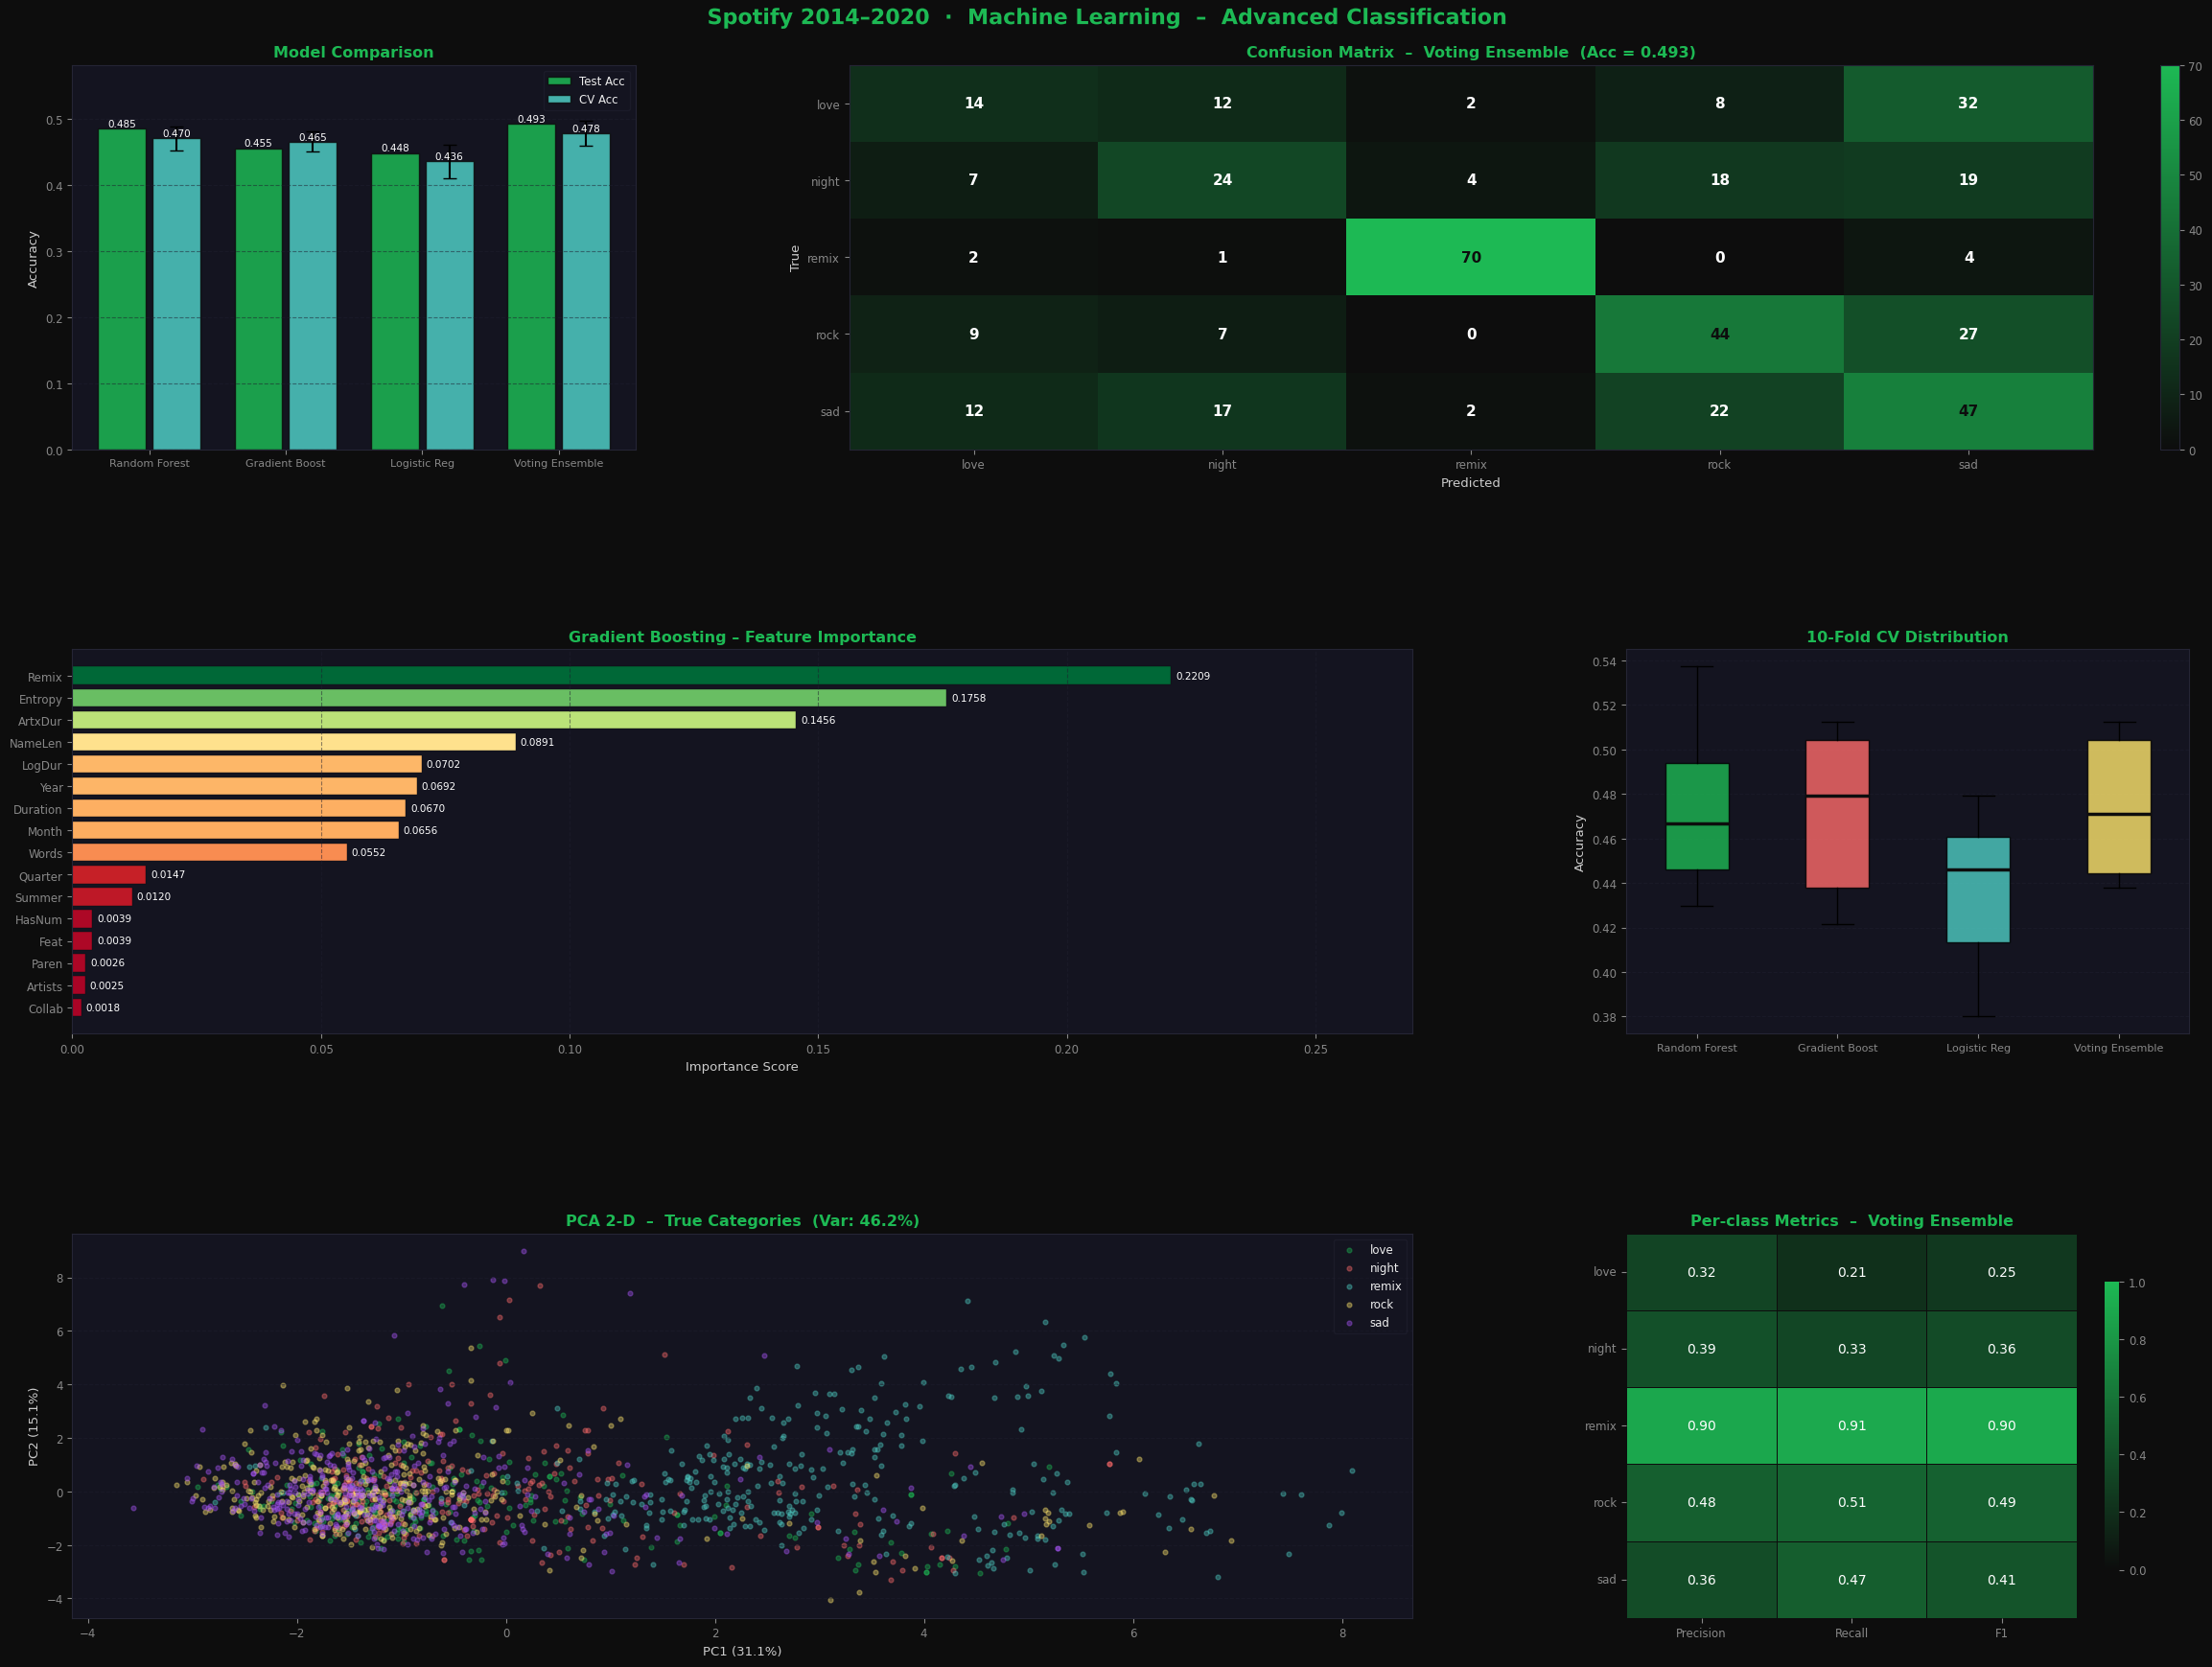

In [18]:
fig7 = plt.figure(figsize=(24, 18), facecolor=BG)
page_title(fig7, 0.977,
           "Spotify 2014–2020  ·  Machine Learning  –  Advanced Classification")
gs7 = gridspec.GridSpec(3, 3, fig7, hspace=0.52, wspace=0.38,
                         top=0.95, bottom=0.05, left=0.05, right=0.97)

# Remove anomalies before training
clean_mask = df["Is_Anomaly"] == 0
X_ml = df.loc[clean_mask, FEATURE_COLS].values
y_ml = df.loc[clean_mask, "Query_Encoded"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_ml, y_ml, test_size=0.25, random_state=42, stratify=y_ml)

sc_ml    = StandardScaler()
X_tr_s   = sc_ml.fit_transform(X_tr)
X_te_s   = sc_ml.transform(X_te)

rf_ml    = RandomForestClassifier(n_estimators=350, max_depth=14,
                                   min_samples_leaf=2, random_state=42)
gb_ml    = GradientBoostingClassifier(n_estimators=250, learning_rate=0.07,
                                       max_depth=5, subsample=0.85,
                                       random_state=42)
lr_ml    = LogisticRegression(C=1.5, max_iter=1000, random_state=42)
ens_ml   = VotingClassifier(
               [("rf", rf_ml), ("gb", gb_ml), ("lr", lr_ml)],
               voting="soft")

MODELS = {"Random\nForest": rf_ml, "Gradient\nBoost": gb_ml,
          "Logistic\nReg": lr_ml, "Voting\nEnsemble": ens_ml}

results7 = {}
for name, mdl in MODELS.items():
    mdl.fit(X_tr_s, y_tr)
    pred = mdl.predict(X_te_s)
    cv   = cross_val_score(mdl, X_tr_s, y_tr, cv=5, scoring="accuracy")
    results7[name] = {"acc": accuracy_score(y_te, pred),
                       "cv":  cv.mean(), "cv_std": cv.std(), "pred": pred}
    print(f"  {name.replace(chr(10),' '):20s}  "
          f"Acc={accuracy_score(y_te,pred):.3f}  "
          f"CV={cv.mean():.3f}±{cv.std():.3f}")

# ── 7-A  Model comparison bar
ax = fig7.add_subplot(gs7[0, 0])
style_ax(ax)
names7 = list(results7.keys())
accs7  = [results7[n]["acc"] for n in names7]
cvs7   = [results7[n]["cv"]  for n in names7]
cvs7s  = [results7[n]["cv_std"] for n in names7]
xb7    = np.arange(len(names7))
b1_ = ax.bar(xb7 - 0.2, accs7, 0.35, label="Test Acc",
             color=SPOTIFY_GREEN, alpha=0.85, edgecolor=BG)
b2_ = ax.bar(xb7 + 0.2, cvs7, 0.35, yerr=cvs7s,
             label="CV Acc", color="#4ECDC4", alpha=0.85,
             capsize=5, edgecolor=BG)
for b, v in zip(list(b1_) + list(b2_), accs7 + cvs7):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
            f"{v:.3f}", ha="center", fontsize=7.5, color="white")
ax.set_xticks(xb7)
ax.set_xticklabels([n.replace("\n", " ") for n in names7], fontsize=8)
ax.set_ylim(0, max(accs7 + cvs7) * 1.18)
ax.set_title("Model Comparison", color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Accuracy")
ax.legend()

# ── 7-B  Best model – Confusion matrix
best_name7 = max(results7, key=lambda n: results7[n]["acc"])
best_pred7 = results7[best_name7]["pred"]
ax = fig7.add_subplot(gs7[0, 1:])
style_ax(ax, None)
cm7 = confusion_matrix(y_te, best_pred7)
im7 = ax.imshow(cm7, cmap=GREEN_CMAP, aspect="auto")
plt.colorbar(im7, ax=ax, fraction=0.022)
for i in range(cm7.shape[0]):
    for j in range(cm7.shape[1]):
        ax.text(j, i, str(cm7[i, j]),
                ha="center", va="center", fontsize=11, fontweight="bold",
                color=BG if cm7[i, j] > cm7.max() * 0.5 else "white")
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_)
ax.set_yticklabels(le.classes_)
ax.set_title(f"Confusion Matrix  –  {best_name7.replace(chr(10),' ')}  "
             f"(Acc = {results7[best_name7]['acc']:.3f})",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
# ── 7-C  GBM feature importance (horizontal)
ax = fig7.add_subplot(gs7[1, :2])
style_ax(ax, "x")
gb_imp  = gb_ml.feature_importances_
sidx7   = np.argsort(gb_imp)
FEAT_LBL = ["Duration", "LogDur", "Artists", "NameLen", "Year",
             "Collab", "Words", "Feat", "Remix", "HasNum",
             "Paren", "Entropy", "ArtxDur", "Month", "Quarter", "Summer"]
clrs_fi = plt.cm.RdYlGn(gb_imp[sidx7] / gb_imp.max())
ax.barh([FEAT_LBL[i] for i in sidx7], gb_imp[sidx7],
         color=clrs_fi, edgecolor=BG, linewidth=0.3)
for i, (idx, v) in enumerate(zip(sidx7, gb_imp[sidx7])):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center",
            fontsize=7.5, color="white")
ax.set_title("Gradient Boosting – Feature Importance",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_xlim(0, gb_imp.max() * 1.22)

# ── 7-D  10-fold CV box per model
ax = fig7.add_subplot(gs7[1, 2])
style_ax(ax)
cv10 = {n: cross_val_score(m, X_tr_s, y_tr, cv=10)
        for n, m in MODELS.items()}
bp7 = ax.boxplot(list(cv10.values()), patch_artist=True,
                 medianprops={"color": BG, "lw": 2.5},
                 flierprops={"marker": ".", "ms": 4.5, "alpha": 0.55,
                              "markerfacecolor": "#FF6B6B"})
for patch, c in zip(bp7["boxes"], PALETTE):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_xticklabels([n.replace("\n", " ") for n in cv10], fontsize=8)
ax.set_title("10-Fold CV Distribution",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_ylabel("Accuracy")

# ── 7-E  PCA 2-D coloured by true category
ax = fig7.add_subplot(gs7[2, :2])
style_ax(ax)
pca7  = PCA(n_components=2, random_state=42)
Xp7   = pca7.fit_transform(sc_ml.transform(X_ml))
for i, cls in enumerate(le.classes_):
    m = y_ml == i
    ax.scatter(Xp7[m, 0], Xp7[m, 1],
               color=PALETTE[i], alpha=0.38, s=12, label=cls)
ax.set_title(f"PCA 2-D  –  True Categories  "
             f"(Var: {pca7.explained_variance_ratio_.sum()*100:.1f}%)",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca7.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca7.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend()
# ── 7-F  Per-class precision / recall / F1 heatmap
ax = fig7.add_subplot(gs7[2, 2])
style_ax(ax, None)
rep = classification_report(y_te, best_pred7, target_names=le.classes_,
                             output_dict=True)
pr_df = pd.DataFrame(
    {cls: [rep[cls]["precision"], rep[cls]["recall"], rep[cls]["f1-score"]]
     for cls in le.classes_},
    index=["Precision", "Recall", "F1"]).T
sns.heatmap(pr_df, ax=ax, cmap=GREEN_CMAP, annot=True, fmt=".2f",
            vmin=0, vmax=1, annot_kws={"size": 10},
            linewidths=0.4, linecolor=BG,
            cbar_kws={"shrink": 0.75})
ax.set_title(f"Per-class Metrics  –  {best_name7.replace(chr(10),' ')}",
             color=SPOTIFY_GREEN, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig7.savefig("/Users/canberkyilmaz/Desktop/spoti_proje/page7_ml.png", dpi=150,
             bbox_inches="tight", facecolor=BG)
print("✓  Page 7 – Machine Learning saved")